#Simple Documentation

---



- Most Important notes across the notebook:
- the code is a google colab friendly . bec the code include images and notes thant won't display in other environments.
- the full code time complexity equal to 34 min .

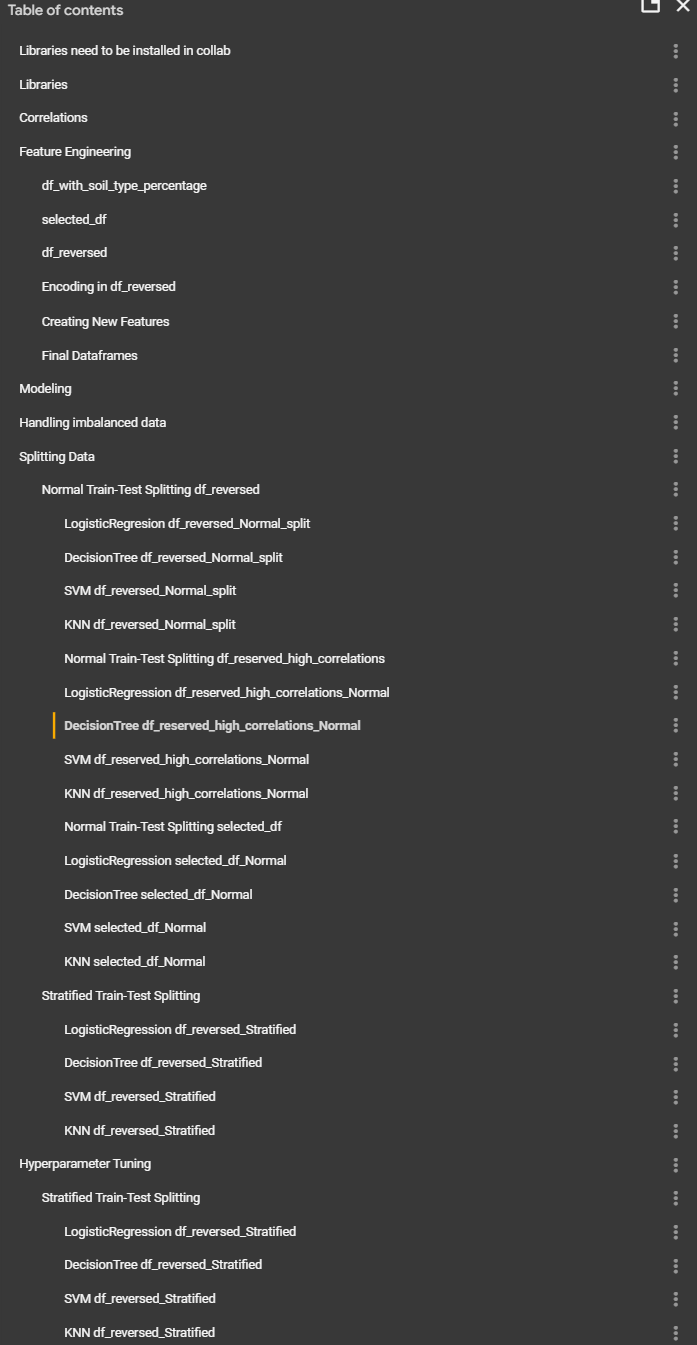



**Feature Engineering Section**

WE HAVE in the data

Wilderness_Area column that been encoded to 4 columns .
soil type that have been encoded to 40 column

For all data frames the 40 hot encoded feature of soil
Type reversed (decoded) .i did decode Wilderness_Area column but not always. i drop some of their columns in some data frames:



- df_reversed shape (581012, 15) the soil type and Wilderness_Area column decoded and then encoded to target encoding . and 2 other engineered features were added.
target encoded features correlations.
['Cover_Type']['Soil_Type_Encoded']=0.5224127824455165
['Cover_Type']['Wilderness_Area_Encoded']=0.35417342624062925


- df_revered_high_correlation shape (581012, 9) same as df_reversed but very low correlated features were eliminated

- selected_df shape (581012, 18) the soil type encoded to percentage of type  ['Soil_Type_Percentage'] with -0.23 correlation and the rest columns selected was columns have a correlation higher than 10% with the target . there was 16 feature with the target in the dataframe .then encoded features from df_reversed have been added because of their high correlation with the target.
(The correlation we get from the new column higher than the 40 encoded features So in this df the 40 hot encoded feature were droppped and encoded into one new column name ['Soil_Type_Percentage'])




**Splitting Data Section**

This section consist of 12 trained model on 3 different dataset
Below How the Splitting section input (3 dataframes) and output the best performed dataframe across models.

To depend best splitting and best data frame i apply for each dataframe:
1. normal splitting
2. oversampling (SMOTE)
3. standarization

best one df then again apply on it :  
1. stratified splitting
2. oversampling (SMOTE)
3. standarization


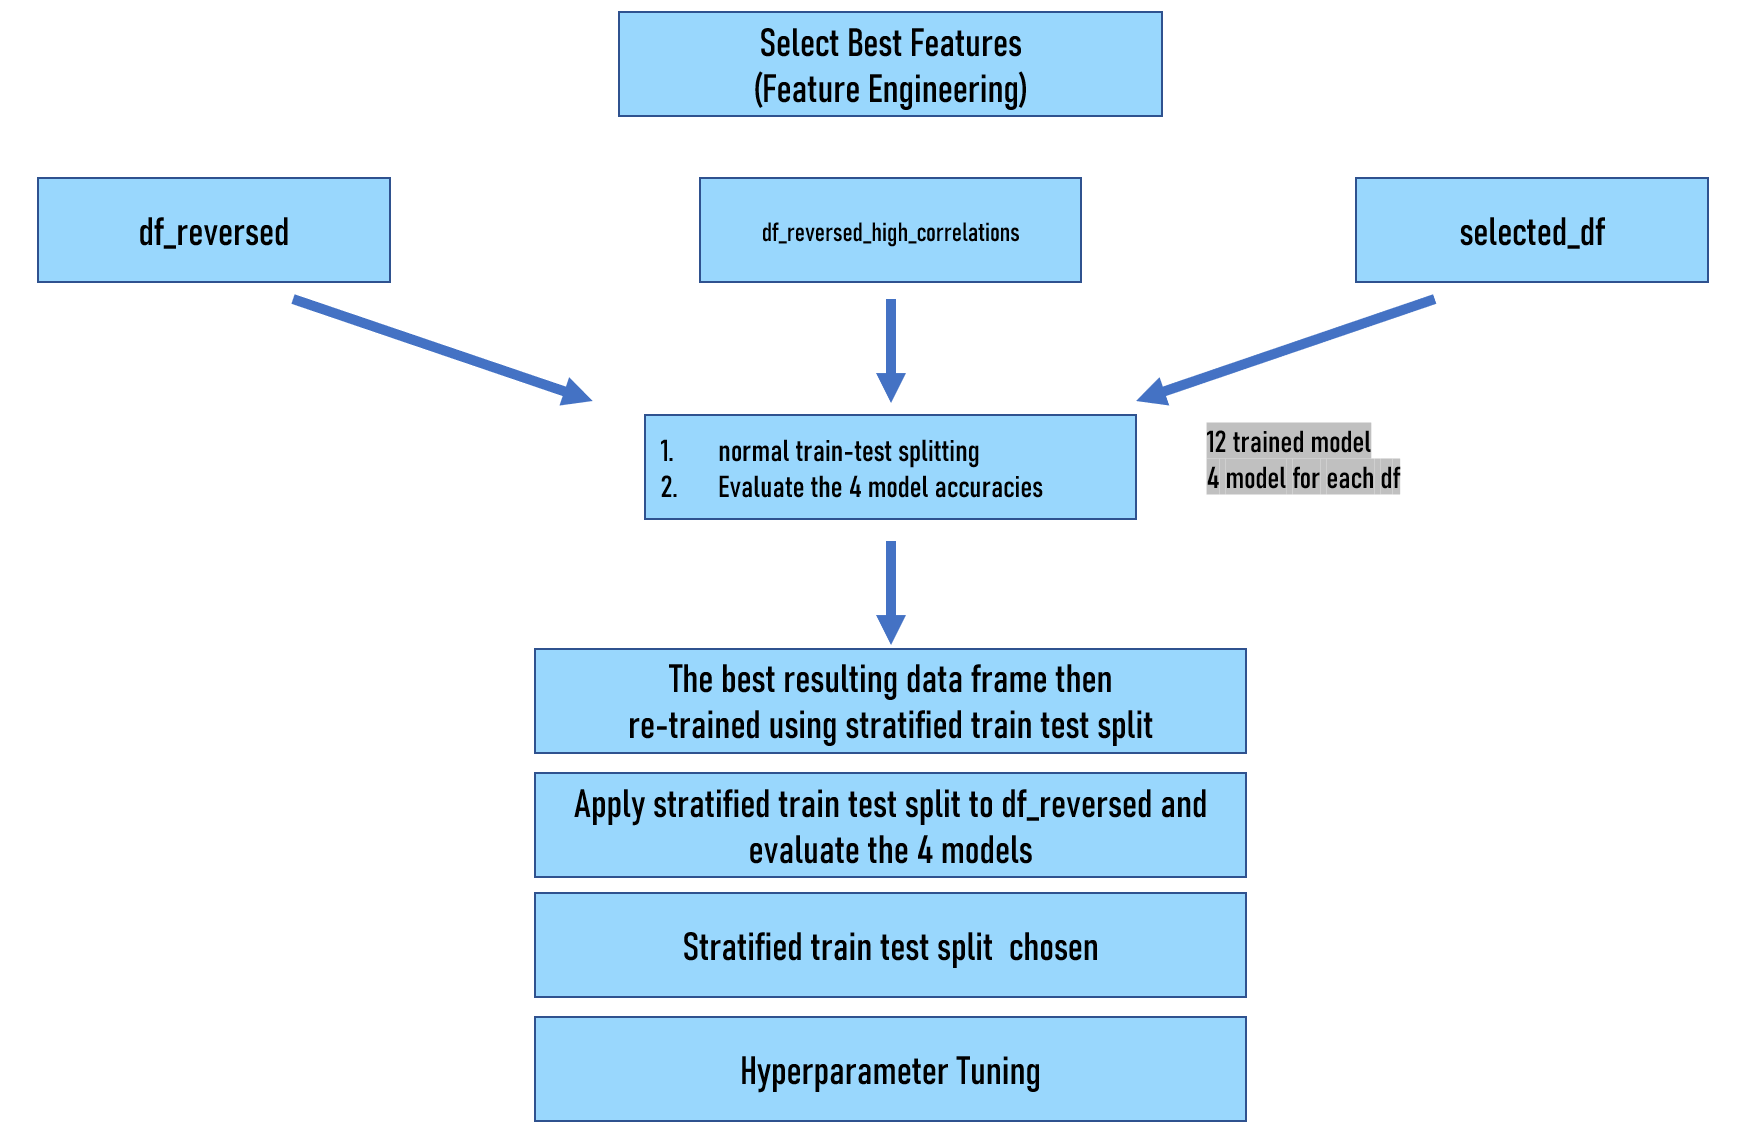

The results that lead to choose df_reversed (stratified split) to choose to enter to hyperparameter tuning section.


Before Tuning df_reversed stratified split

After df_reversed stratified split **tuned**



```
BEFORE TUNING RESULTS BELOW
```



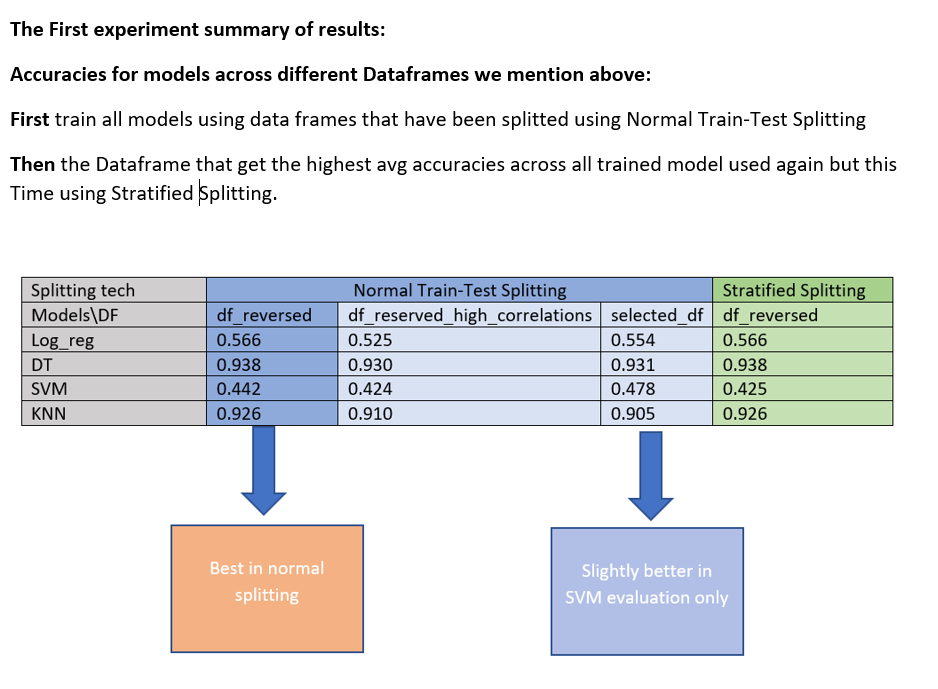






```
AFTER TUNING RESULTS (Dataset : train test validate)
```



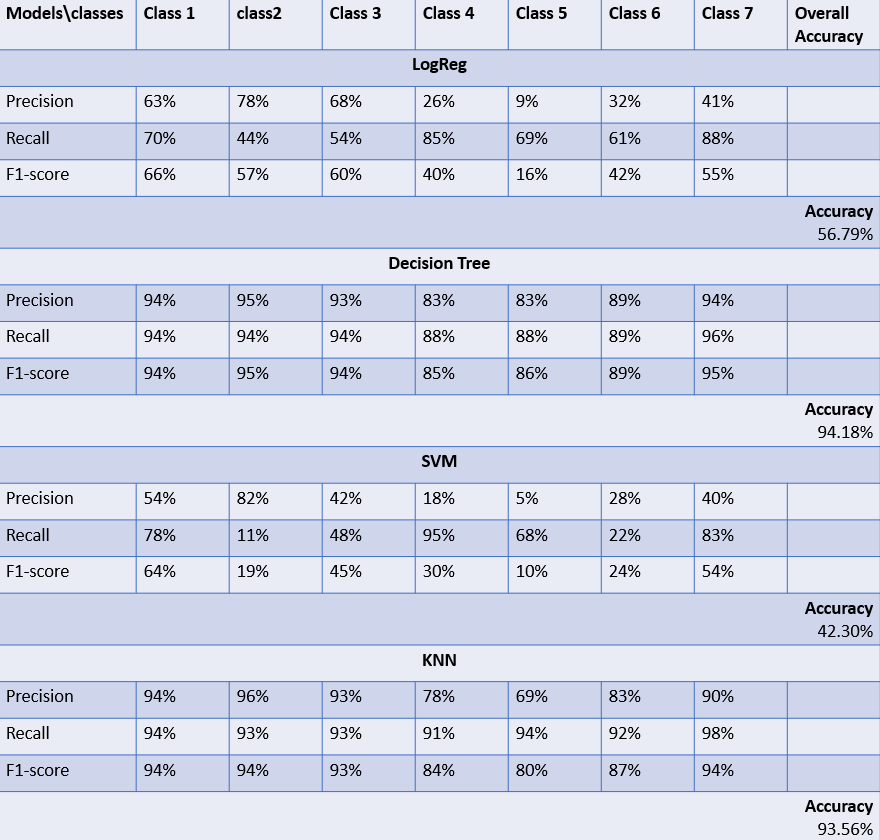



```
Comparison
```



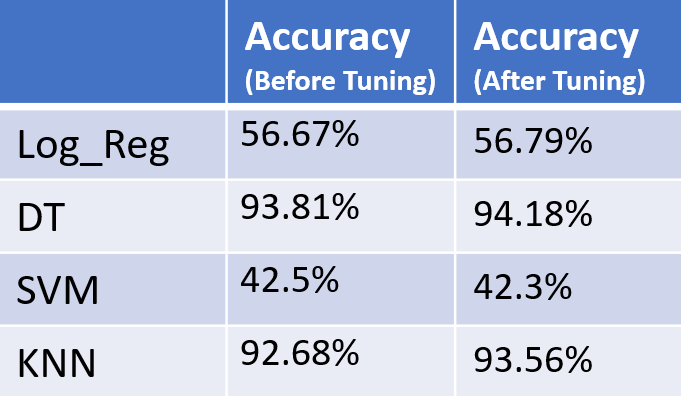

** These last sections have the before and after tuning code  **

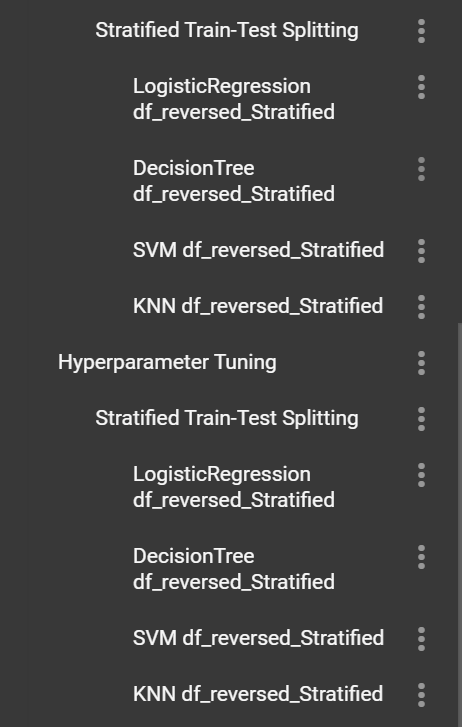

**Hyperparameter Tuning method**
1. split the data into test validate train
2. undersample the data
3. scale the undersampled data
4. get the best parameters using RandomizedSearchCV on the undersampled scaled data
5. oversample (SMOTE) the original data set
6. scale the oversampled data (standarization)
7. apply the best parameters to the oversampled scaled data

**Notes that limit some experiments:**
- i initialy start with the data splitted only test- train
- the objective of the analysis is to score 78% for accuracy for at least one on the models (logistic regression , svm , knn , decision tree).
- knn and decision tree reach a great result above the target .
- time for the task have been taken under consideration that is why some experiments have not been done yet.  

**How parameters of random search choosed ?**
Because grid search took a lot of time running . RandomizedSearchCV been used only in the notebook.
- logistic regression : at first i try to set random search to search across high number of parameters and parameters value . the code took more than hour to run and never give any result . so i decreased the number of parameters and values . still took along time to run but start to give results.

Accuracy of the model across best parameters without validate set:

1st 0.6811962239052154 => Best Hyperparameters from RandomizedSearchCV: {'solver': 'saga', 'penalty': 'l2', 'max_iter': 100, 'class_weight': 'balanced', 'C': 19306.977288832535}

2nd 0.6822052466155382 => Best Hyperparameters from RandomizedSearchCV: {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 200, 'class_weight': 'balanced', 'C': 162.37767391887175}

3rd 0.6823111410529034 => Best Hyperparameters from RandomizedSearchCV: {'solver': 'newton-cg', 'penalty': 'l2', 'max_iter': 500, 'class_weight': 'balanced', 'C': 2976.3514416313133}

4th 0.6823111410529034 => Best Hyperparameters from RandomizedSearchCV: {'solver': 'newton-cg', 'penalty': 'l2', 'max_iter': 1500, 'class_weight': None, 'C': 162.37767391887175}

5th 3h 2m 10s Here i increase the parameters and number of values in the random search The previous was way more better because it took approx less than 10 min running

0.6845313944229938 => Best Hyperparameters from RandomizedSearchCV: {'solver': 'lbfgs', 'penalty': 'l2', 'multi_class': 'multinomial', 'max_iter': 3000, 'class_weight': 'balanced', 'C': 1438.449888287663}

final 1 min time compelexity 0.6823182006820611 => Best Hyperparameters from RandomizedSearchCV: {'solver': 'newton-cg', 'penalty': 'l2', 'max_iter': 100, 'class_weight': 'balanced', 'C': 2000.0000000000002}


the results was great and the time complexity decreased because i was decreasing number of value parameter depending on the best values for the pre experiments.

the 68% was the best that i reached and i couldn't make it any higher.

Now :(
  for svm knn DT i split the data into train test and validate and because i did this i was obligated to do the same to logistic regression but it become a mess from 68% down to 56.7%. i tried to change the portion of training set but there was not any achievement . I deleted the code for the pre result beacuse the code was realy too long .

  'tol' parameter i figured so late make the logistic regression run insanely fast.this parameter happen to help speed up the training process. By allowing the model to stop early when changes in the loss are small (similar to early stopping)

- KNN and DT reach higher than the result from the start . i initialized DT with reasonable number of parameters . the results was great . validation and testing sets score was too close which hopefully tells that there was no overfitting.

- SVM : this model does take a lot of time running so i used linear svm which is the SGDClassifier(loss='hinge', random_state=42) still in hyper parameter tuning in took 9 min running . reasonable "not more than hour :("

- SVM and KNN took good number of parameters the random search took 10 min training for each model .

- 250 iter and cv =5 fixed parameters

Regularization method have different parameter in each model.

**BEST PARAMETERS**

Best Hyperparameters from RandomizedSearchCV for LogisticRegression: {'tol': 2.0, 'solver': 'saga', 'penalty': 'l1', 'multi_class': 'auto', 'max_iter': 3000, 'class_weight': 'balanced', 'C': 2.0691380811147897}

Best Hyperparameters from RandomizedSearchCV for LogisticRegression: {'tol': 2.0, 'solver': 'saga', 'penalty': 'l1', 'multi_class': 'auto', 'max_iter': 3000, 'class_weight': 'balanced', 'C': 2.0691380811147897}


Best Hyperparameters from RandomizedSearchCV for SGDClassifier: {'validation_fraction': 0.1, 'tol': 1e-05, 'shuffle': True, 'penalty': 'elasticnet', 'max_iter': 2000, 'learning_rate': 'optimal', 'eta0': 0.01, 'early_stopping': False, 'alpha': 0.0001}


Best Hyperparameters from RandomizedSearchCV for KNN: {'weights': 'distance', 'p': 2, 'n_neighbors': 3, 'metric': 'manhattan', 'algorithm': 'auto'}

#Libraries need to be installed in collab

In [ ]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.0/82.0 kB 2.2 MB/s eta 0:00:00


In [ ]:
pip install imbalanced-learn


#Libraries

In [ ]:
import numpy as np                      #to deal with arrays and its operations
import plotly.express as px             #visualization library
import matplotlib.pyplot as plt         #visualization library
import seaborn as sns                   #visualization library
import pandas as pd                     #lib that have the datastructures series and dataframe and their operations


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import category_encoders as ce

# models Libraries
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC  # for classification
from sklearn.tree import DecisionTreeClassifier  # For classification
from sklearn.neighbors import KNeighborsClassifier  # For classification
from sklearn.linear_model import LogisticRegression  # For classification
from sklearn.linear_model import SGDClassifier
# evaluation metrices libraries (accuracy, precision, recall, F1-score)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#GridSearchCV and RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler
from sklearn.experimental import enable_halving_search_cv  # To enable the halving search
from sklearn.model_selection import HalvingRandomSearchCV


In [ ]:
df= pd.read_csv('/content/covtype.csv')

In [ ]:
df.shape

(581012, 55)

In [ ]:
# Adjust pandas settings to display all columns
pd.set_option('display.max_columns', None)  # None means no limit
pd.set_option('display.expand_frame_repr', False)  # Prevent line breaks

# Now display the first 5 rows of your DataFrame
df.head(5)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Soil_Type1,Soil_Type2,Soil_Type3,Soil_Type4,Soil_Type5,Soil_Type6,Soil_Type7,Soil_Type8,Soil_Type9,Soil_Type10,Soil_Type11,Soil_Type12,Soil_Type13,Soil_Type14,Soil_Type15,Soil_Type16,Soil_Type17,Soil_Type18,Soil_Type19,Soil_Type20,Soil_Type21,Soil_Type22,Soil_Type23,Soil_Type24,Soil_Type25,Soil_Type26,Soil_Type27,Soil_Type28,Soil_Type29,Soil_Type30,Soil_Type31,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5


In [ ]:
df.shape

(581012, 55)

In [ ]:
df.nunique()

,0
Elevation,1978
Aspect,361
Slope,67
Horizontal_Distance_To_Hydrology,551
Vertical_Distance_To_Hydrology,700
Horizontal_Distance_To_Roadways,5785
Hillshade_9am,207
Hillshade_Noon,185
Hillshade_3pm,255
Horizontal_Distance_To_Fire_Points,5827


In [ ]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1',
       'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4',
       'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5',
       'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10',
       'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14',
       'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18',
       'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22',
       'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26',
       'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
       'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34',
       'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38',
       'Soil_Type39', 'Soil_Type40

In [ ]:
df['Cover_Type'].value_counts()

,count
Cover_Type,
2,283301
1,211840
3,35754
7,20510
6,17367
5,9493
4,2747




```
Imbalanced Data
```



In [ ]:
if df.isnull().sum().sum() == 0:
    print("There are no missing values in the dataset.")
else:
    print(f"There are {df.isnull().sum().sum()} missing values in the dataset.")

There are no missing values in the dataset.


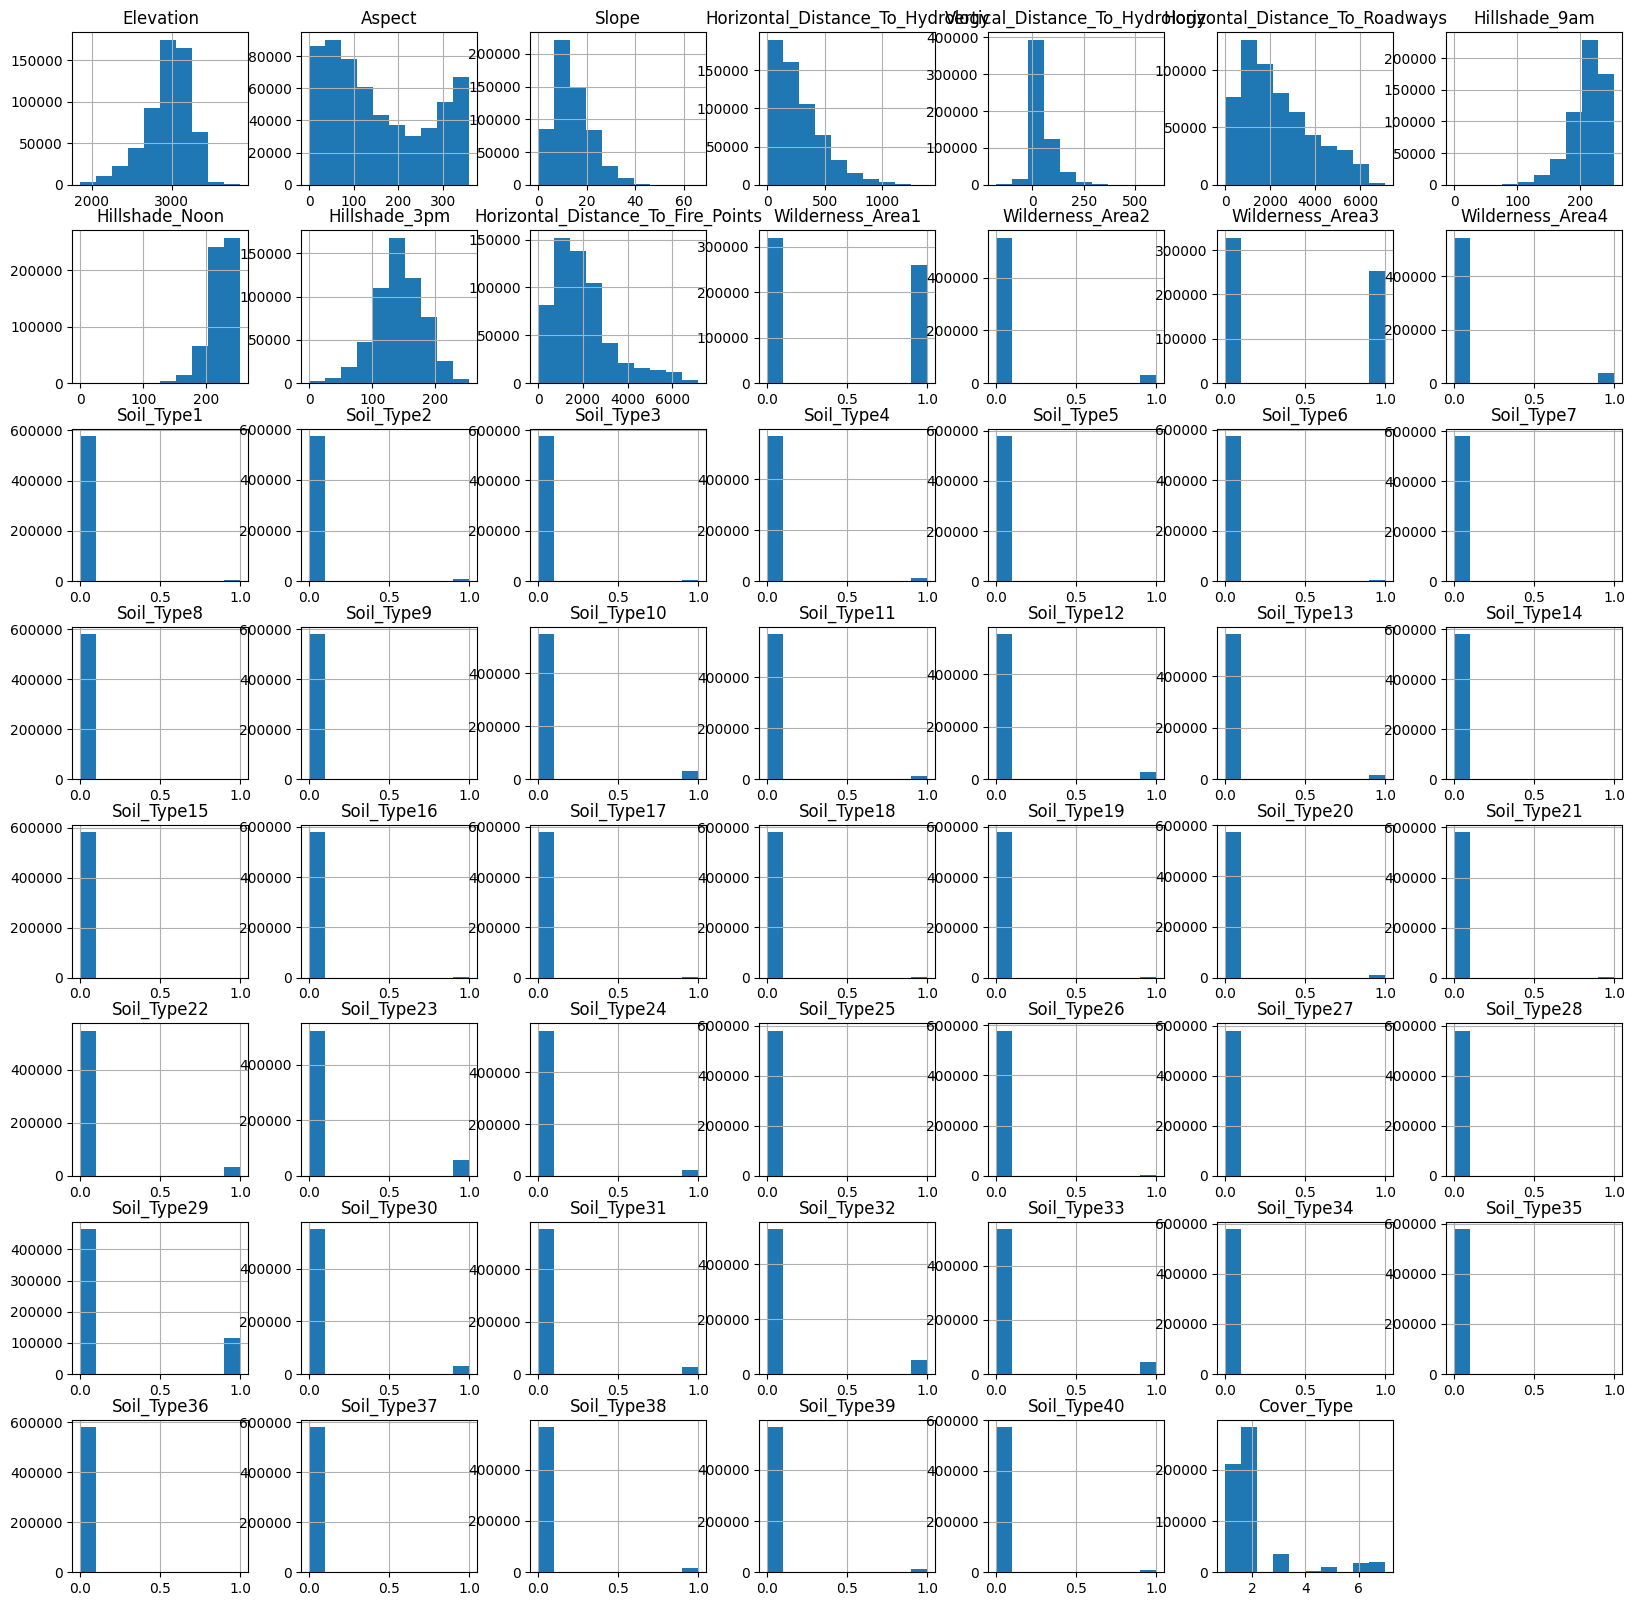

In [ ]:
df.hist(figsize=(20,20))
plt.show()

#Correlations

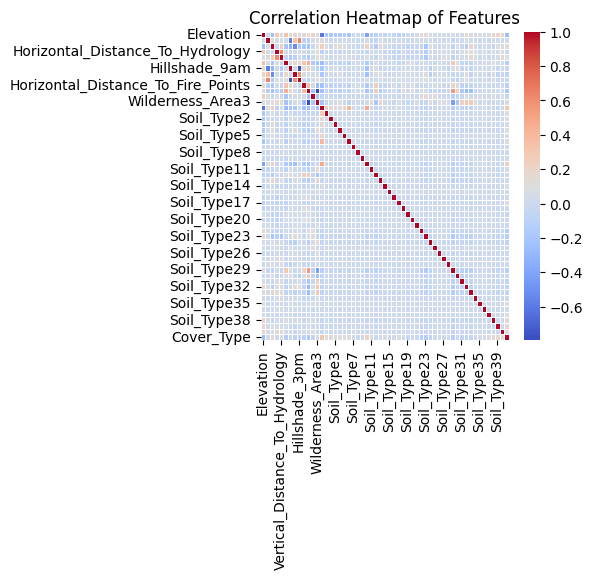

In [ ]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Plot a heatmap using seaborn
plt.figure(figsize=(4,4))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Features")
plt.show()

In [ ]:
# displaying the  pairs where the correlation is greater than or equal to 0.9
# Calculate the correlation matrix
corr_matrix =df.corr().abs()

# Find pairs where the correlation is greater than or equal to 0.9, excluding self-correlation
high_corr_pairs = (corr_matrix.where(corr_matrix >= 0.7)
                   .stack()  # Stack the dataframe to get feature pairs
                   .reset_index()  # Reset the index
                   .rename(columns={0: 'Correlation'})  # Rename the correlation column
                   .query("Correlation < 1")  # Exclude self-correlation (correlation = 1)
                   .sort_values(by='Correlation', ascending=False))  # Sort by correlation

# Print the pairs
for index, row in high_corr_pairs.iterrows():
    print(f"{row['level_0']} and {row['level_1']} have a correlation of {row['Correlation']:.2f}")

Wilderness_Area1 and Wilderness_Area3 have a correlation of 0.79
Wilderness_Area3 and Wilderness_Area1 have a correlation of 0.79
Hillshade_9am and Hillshade_3pm have a correlation of 0.78
Hillshade_3pm and Hillshade_9am have a correlation of 0.78


In [ ]:
# displaying the  pairs where the correlation is greater than or equal to 0.7 and less than 0.9
# Find pairs where the correlation is greater than or equal to 0.9, excluding self-correlation
high_corr_pairs = (corr_matrix.where((corr_matrix >= 0.5) & (corr_matrix <= 0.7 ))
                   .stack()  # Stack the dataframe to get feature pairs
                   .reset_index()  # Reset the index
                   .rename(columns={0: 'Correlation'})  # Rename the correlation column
                   .query("Correlation < 1")  # Exclude self-correlation (correlation = 1)
                   .sort_values(by='Correlation', ascending=False))  # Sort by correlation

# Print the pairs
for index, row in high_corr_pairs.iterrows():
    print(f"{row['level_0']} and {row['level_1']} have a correlation of {row['Correlation']:.2f}")

Aspect and Hillshade_3pm have a correlation of 0.65
Hillshade_3pm and Aspect have a correlation of 0.65
Elevation and Wilderness_Area4 have a correlation of 0.62
Wilderness_Area4 and Elevation have a correlation of 0.62
Horizontal_Distance_To_Hydrology and Vertical_Distance_To_Hydrology have a correlation of 0.61
Vertical_Distance_To_Hydrology and Horizontal_Distance_To_Hydrology have a correlation of 0.61
Hillshade_Noon and Hillshade_3pm have a correlation of 0.59
Hillshade_3pm and Hillshade_Noon have a correlation of 0.59
Aspect and Hillshade_9am have a correlation of 0.58
Hillshade_9am and Aspect have a correlation of 0.58
Wilderness_Area1 and Soil_Type29 have a correlation of 0.55
Soil_Type29 and Wilderness_Area1 have a correlation of 0.55
Slope and Hillshade_Noon have a correlation of 0.53
Hillshade_Noon and Slope have a correlation of 0.53


In [ ]:
count = 0
for i, dtype in zip(df.columns, df.dtypes):
    if dtype != 'int64':
        count += 1
print(count, "not integer , ALL these features DType in df equal to int64 ")

0 not integer , ALL these features DType in df equal to int64 


In [ ]:
# Features correlations with the target
arr = []

for i in df.columns:
  correlation = df['Cover_Type'].corr(df[i])
  print(i,"   ", correlation)
  arr.append(correlation)

arr_df = pd.DataFrame(arr, columns=['Correlation'], index=df.columns)

# Sort the correlations for finding second highest and least
sorted_correlations = arr_df['Correlation'].sort_values(ascending=False)

# Second highest correlation
second_highest_correlation = sorted_correlations.iloc[1]
second_highest_feature = sorted_correlations.index[1]

# Least correlation (excluding self-correlation of 1)
least_correlation = sorted_correlations[sorted_correlations < 1].iloc[-1]  # Exclude 1 and get last
least_correlated_feature = sorted_correlations[sorted_correlations < 1].index[-1]



Elevation     -0.2695537776305046
Aspect     0.01707980203277439
Slope     0.14828540507947854
Horizontal_Distance_To_Hydrology     -0.02031662163693511
Vertical_Distance_To_Hydrology     0.08166402150981587
Horizontal_Distance_To_Roadways     -0.15344975909042438
Hillshade_9am     -0.03541500364669965
Hillshade_Noon     -0.09642600166233195
Hillshade_3pm     -0.04828973004683906
Horizontal_Distance_To_Fire_Points     -0.1089355361032271
Wilderness_Area1     -0.20391321381925523
Wilderness_Area2     -0.048058949741315506
Wilderness_Area3     0.06684564296338873
Wilderness_Area4     0.32319955390915706
Soil_Type1     0.0908281521174632
Soil_Type2     0.11813526031668564
Soil_Type3     0.06806445519051252
Soil_Type4     0.09967186439491378
Soil_Type5     0.07788996111809236
Soil_Type6     0.1129582780721208
Soil_Type7     -0.0004955165229846159
Soil_Type8     -0.003666793589918535
Soil_Type9     -0.006109533783057264
Soil_Type10     0.2438763015279522
Soil_Type11     0.035378737686072734

In [ ]:
# Print the results
print(f"maximum positive correlation with the target: {second_highest_feature}, Correlation: {second_highest_correlation}")
print(f"maximum negative correlation: {least_correlated_feature}, Correlation: {least_correlation}")

maximum positive correlation with the target: Wilderness_Area4, Correlation: 0.32319955390915706
maximum negative correlation: Elevation, Correlation: -0.2695537776305046


`The highest negative and positive correlations indicate that there is no high correlation with the target `

#Feature Engineering

**==>> WE HAVE**
1. Wilderness_Area column that been encoded to 4 columns .
2. soil type that have been encoded to 40 column

In [ ]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1',
       'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4',
       'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5',
       'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10',
       'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14',
       'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18',
       'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22',
       'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26',
       'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
       'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34',
       'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38',
       'Soil_Type39', 'Soil_Type40




**==>> Test cases dataframes:**

We have these dataframes:
1. df_with_soil_type_percentage : we reverse the encoding and instead of the categorical column we replace it with a column that maps each soil type to the percentage of records in the dataset where that soil type occurs (i.e., the percentage of 1s in that specific soil type column).
2. selected_df: with the 16 highest correlated features with the target "including the target" .the features which selected have a correlation equal or
higher to 0.1 wether it is negative or positive correlation (random expirement)
3. target_encoded_df: the 40 hot encoded features reversed .and target encoded applied to the column instead.







```
The dataset  has 40 one-hot encoded columns for
different soil types.They are all sparse columns
```



###df_with_soil_type_percentage

In [ ]:
# calculate number of ones and zeros for every column
# Select all soil type columns
soil_columns = [col for col in df.columns if 'Soil_Type' in col]

# Create a dictionary to store the count of 0s and 1s for each soil type
soil_type_counts = {}

# Total number of rows in the dataset (for percentage calculation)
total_rows = len(df)

# Loop through each soil type column and count the occurrences of 0 and 1, calculate correlation
for col in soil_columns:
    counts = df[col].value_counts()
    # Ensure both 0 and 1 are captured, filling missing values with 0 if necessary
    soil_type_counts[col] = {
        '0s': counts.get(0, 0),
        '1s': counts.get(1, 0),
        'Percentage of 1s': counts.get(1, 0) / total_rows * 100,  # Calculate percentage of 1s
        'Correlation with Cover_Type': df[col].corr(df['Cover_Type'])  # Calculate correlation with target
    }

# Convert the dictionary into a DataFrame for better visualization
soil_type_counts_df = pd.DataFrame(soil_type_counts).T

# Sort the DataFrame by the '1s' column in descending order
soil_type_counts_df_sorted = soil_type_counts_df.sort_values(by='1s', ascending=False)

# Display sorted result
soil_type_counts_df_sorted

,0s,1s,Percentage of 1s,Correlation with Cover_Type
Soil_Type29,465765.0,115247.0,19.835563,-0.124933
Soil_Type23,523260.0,57752.0,9.939898,-0.135055
Soil_Type32,528493.0,52519.0,9.039228,-0.075562
Soil_Type33,535858.0,45154.0,7.771612,-0.062502
Soil_Type22,547639.0,33373.0,5.743943,-0.141746
Soil_Type10,548378.0,32634.0,5.616751,0.243876
Soil_Type30,550842.0,30170.0,5.192664,-0.010436
Soil_Type12,551041.0,29971.0,5.158413,-0.023601
Soil_Type31,555346.0,25666.0,4.417465,-0.065347
Soil_Type24,559734.0,21278.0,3.662231,-0.068746



```
# can i take the percentage column instead of the 40 encoded features ?
# what is the different between this and target encoding ?
# should i reverse the encoding and do target encoding

```



In [ ]:
#  Create a dictionary mapping each Soil_Type column to its percentage of 1s
df_with_soil_type_percentage = df.copy()
percentage_mapping = {
    'Soil_Type1': 0.521676, 'Soil_Type2': 1.295154, 'Soil_Type3': 0.830103, 'Soil_Type4': 2.133519,
    'Soil_Type5': 0.274865, 'Soil_Type6': 1.131646, 'Soil_Type7': 0.018072, 'Soil_Type8': 0.030808,
    'Soil_Type9': 0.197414, 'Soil_Type10': 5.616751, 'Soil_Type11': 2.135928, 'Soil_Type12': 5.158413,
    'Soil_Type13': 3.000110, 'Soil_Type14': 0.103096, 'Soil_Type15': 0.000516, 'Soil_Type16': 0.489663,
    'Soil_Type17': 0.588972, 'Soil_Type18': 0.326844, 'Soil_Type19': 0.692068, 'Soil_Type20': 1.593599,
    'Soil_Type21': 0.144231, 'Soil_Type22': 5.743943, 'Soil_Type23': 9.939898, 'Soil_Type24': 3.662231,
    'Soil_Type25': 0.081582, 'Soil_Type26': 0.445602, 'Soil_Type27': 0.186915, 'Soil_Type28': 0.162819,
    'Soil_Type29': 19.835563, 'Soil_Type30': 5.192664, 'Soil_Type31': 4.417465, 'Soil_Type32': 9.039228,
    'Soil_Type33': 7.771612, 'Soil_Type34': 0.277275, 'Soil_Type35': 0.325467, 'Soil_Type36': 0.020482,
    'Soil_Type37': 0.051290, 'Soil_Type38': 2.680323, 'Soil_Type39': 2.376199, 'Soil_Type40': 1.505993
}

# Create a new column in the original DataFrame that contains the percentage of 1s
# based on the one-hot encoded Soil_Type columns.
def calculate_percentage(row):
    for soil_type, percentage in percentage_mapping.items():
        if row[soil_type] == 1:  # If the soil type column has a value of 1
            return percentage
    return 0  # If no soil type is 1, return 0 (though this shouldn't happen if data is consistent)

df_with_soil_type_percentage['Soil_Type_Percentage'] = df_with_soil_type_percentage.apply(calculate_percentage, axis=1)

# Calculate the correlation between the new percentage feature and the target (Cover_Type)
correlation = df_with_soil_type_percentage['Soil_Type_Percentage'].corr(df_with_soil_type_percentage['Cover_Type'])

# Output the correlation
print(f"Correlation between Soil_Type_Percentage and Cover_Type: {correlation:.4f}")


Correlation between Soil_Type_Percentage and Cover_Type: -0.2353


The correlation we get from the new column higher than the 40 encoded features So in this df the 40 hot encoded feature were droppped and encoded into one new column name ['Soil_Type_Percentage']

In [ ]:
df_with_soil_type_percentage.shape

(581012, 56)

In [ ]:
# List of Soil_Type columns to drop (Soil_Type1 to Soil_Type40)
soil_type_columns = [f'Soil_Type{i}' for i in range(1, 41)]

# Drop the Soil_Type1 to Soil_Type40 columns only if they exist in the DataFrame
df_with_soil_type_percentage.drop(columns=[col for col in soil_type_columns if col in df_with_soil_type_percentage.columns], inplace=True)

# Verify that the columns have been dropped or confirm no error occurs
print(df_with_soil_type_percentage.head(700))  # Display the first few rows of the modified DataFrame


     Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  Hillshade_9am  Hillshade_Noon  Hillshade_3pm  Horizontal_Distance_To_Fire_Points  Wilderness_Area1  Wilderness_Area2  Wilderness_Area3  Wilderness_Area4  Cover_Type  Soil_Type_Percentage
0         2596      51      3                               258                               0                              510            221             232            148                                6279                 1                 0                 0                 0           5             19.835563
1         2590      56      2                               212                              -6                              390            220             235            151                                6225                 1                 0                 0                 0           5             19.835563
2         2804     139      9                    

In [ ]:
df_with_soil_type_percentage.shape

(581012, 16)




1.   Soil Type Encoding: In the dataset, the Soil_Type columns are one-hot encoded. This means that for each record, exactly one of the 40 Soil_Type columns has a value of 1, and the rest have a value of 0.
2.   Percentage of 1s: The percentage_mapping dictionary maps each soil type to the percentage of records in the dataset where that soil type occurs (i.e., the percentage of 1s in that specific soil type column). For example:
If Soil_Type29 has a percentage of 19.835563, it means that 19.8% of all records in the dataset have Soil_Type29 set to 1.
3.  capture how frequent or rare that soil type
is across the dataset



###selected_df

In [ ]:

# These selected columns i select depending on the correlation with the target.
# the columns selected those having a correlation equal to ten percent or more with target
# they result to be 16 column with target
# why equal to ten percent or more?? --> random idea . curious for the result !
selected_columns = [
    'Soil_Type38', 'Soil_Type39', 'Soil_Type40', 'Soil_Type29',
    'Soil_Type22', 'Soil_Type23', 'Soil_Type10', 'Soil_Type6',
    'Soil_Type2', 'Elevation', 'Slope',
    'Horizontal_Distance_To_Roadways', 'Horizontal_Distance_To_Fire_Points',
    'Wilderness_Area1', 'Wilderness_Area4','Cover_Type'
]

# Step 2: Create a new DataFrame with the selected columns
selected_df = df[selected_columns]

# Display the first few rows of the selected DataFrame
selected_df.head()

,Soil_Type38,Soil_Type39,Soil_Type40,Soil_Type29,Soil_Type22,Soil_Type23,Soil_Type10,Soil_Type6,Soil_Type2,Elevation,Slope,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area4,Cover_Type
0,0,0,0,1,0,0,0,0,0,2596,3,510,6279,1,0,5
1,0,0,0,1,0,0,0,0,0,2590,2,390,6225,1,0,5
2,0,0,0,0,0,0,0,0,0,2804,9,3180,6121,1,0,2
3,0,0,0,0,0,0,0,0,0,2785,18,3090,6211,1,0,2
4,0,0,0,1,0,0,0,0,0,2595,2,391,6172,1,0,5


In [ ]:
selected_df.shape

(581012, 16)

In [ ]:
df[soil_columns]

,Soil_Type1,Soil_Type2,Soil_Type3,Soil_Type4,Soil_Type5,Soil_Type6,Soil_Type7,Soil_Type8,Soil_Type9,Soil_Type10,Soil_Type11,Soil_Type12,Soil_Type13,Soil_Type14,Soil_Type15,Soil_Type16,Soil_Type17,Soil_Type18,Soil_Type19,Soil_Type20,Soil_Type21,Soil_Type22,Soil_Type23,Soil_Type24,Soil_Type25,Soil_Type26,Soil_Type27,Soil_Type28,Soil_Type29,Soil_Type30,Soil_Type31,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
581008,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
581009,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
581010,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Encoding

###df_reversed

###Encoding in df_reversed

Reverse the encoding for soil type and wilderness area and then do target encoding instead of one hot encoding

In [ ]:
# Step 1: Reverse One-Hot Encoding for Soil_Type
# Create a single 'Soil_Type' column by finding the column with 1 for each row
df_reversed = df.copy()

# Reverse one-hot encoding for Soil_Type
df_reversed['Soil_Type'] = df[soil_columns].idxmax(axis=1)  # Finds the Soil_Type column with 1
df_reversed['Soil_Type'] = df_reversed['Soil_Type'].str.replace('Soil_Type', '').astype(int)  # Extract the number

# Reverse one-hot encoding for Wilderness_Area
wilderness_columns = ['Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4']
df_reversed['Wilderness_Area'] = df[wilderness_columns].idxmax(axis=1)  # Finds the Wilderness_Area column with 1
df_reversed['Wilderness_Area'] = df_reversed['Wilderness_Area'].str.replace('Wilderness_Area', '').astype(int)  # Extract the number

print(df_reversed[['Soil_Type','Wilderness_Area']].head())

   Soil_Type  Wilderness_Area
0         29                1
1         29                1
2         12                1
3         30                1
4         29                1


In [ ]:
# Drop the original one-hot encoded columns
soil_columns_to_drop = [col for col in soil_columns if col in df_reversed.columns]
wilderness_columns_to_drop = [col for col in wilderness_columns if col in df_reversed.columns]

# Step 2: Apply Target Encoding to Soil_Type and Wilderness_Area
encoder = ce.TargetEncoder(cols=['Soil_Type', 'Wilderness_Area'])

# Apply target encoding
df_encoded = encoder.fit_transform(df_reversed[['Soil_Type', 'Wilderness_Area']], df_reversed['Cover_Type'])

# Add the encoded columns back to the DataFrame
df_reversed['Soil_Type_Encoded'] = df_encoded['Soil_Type']
df_reversed['Wilderness_Area_Encoded'] = df_encoded['Wilderness_Area']

df_reversed.drop(columns=['Soil_Type', 'Wilderness_Area'], inplace=True)
# Step 3: Display only the encoded columns since original columns were dropped
print(df_reversed[['Soil_Type_Encoded', 'Wilderness_Area_Encoded']].head())


   Soil_Type_Encoded  Wilderness_Area_Encoded
0           1.700730                 1.735928
1           1.700730                 1.735928
2           1.910146                 1.735928
3           1.989195                 1.735928
4           1.700730                 1.735928


In [ ]:
print(df_reversed['Cover_Type'].corr(df_reversed['Soil_Type_Encoded']))
print(df_reversed['Cover_Type'].corr(df_reversed['Wilderness_Area_Encoded']))

0.5224127824455165
0.35417342624062925




```
Best correlations until now
```



In [ ]:
df_reversed.shape

(581012, 57)

In [ ]:
df_reversed.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1',
       'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4',
       'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5',
       'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10',
       'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14',
       'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18',
       'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22',
       'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26',
       'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
       'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34',
       'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38',
       'Soil_Type39', 'Soil_Type40

In [ ]:
df_reversed=df_reversed[['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points',
       'Soil_Type_Encoded',
       'Wilderness_Area_Encoded','Cover_Type' ]].copy()
print(df_reversed.shape)
print(df_reversed.columns)
df_reversed.head()

(581012, 13)
Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Soil_Type_Encoded',
       'Wilderness_Area_Encoded', 'Cover_Type'],
      dtype='object')


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Soil_Type_Encoded,Wilderness_Area_Encoded,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,1.700730,1.735928,5
1,2590,56,2,212,-6,390,220,235,151,6225,1.700730,1.735928,5
2,2804,139,9,268,65,3180,234,238,135,6121,1.910146,1.735928,2
3,2785,155,18,242,118,3090,238,238,122,6211,1.989195,1.735928,2
4,2595,45,2,153,-1,391,220,234,150,6172,1.700730,1.735928,5


## Creating New Features

In [ ]:
newfeatures_df = df.copy()


In [ ]:
# Create new engineered features on newfeatures_df

# Two new features one calculate the Sum of distances
# the second calculate the ratio for these 2 distances:
#(['Horizontal_Distance_To_Hydrology'],['Horizontal_Distance_To_Roadways'])

newfeatures_df['Hydrology_Roadways_Dist'] = newfeatures_df['Horizontal_Distance_To_Hydrology'] + newfeatures_df['Horizontal_Distance_To_Roadways']
newfeatures_df['Hydrology_to_Roadways_Ratio'] = newfeatures_df['Horizontal_Distance_To_Hydrology'] / (newfeatures_df['Horizontal_Distance_To_Roadways'] + 1)


#  Polynomial feature: Elevation squared
newfeatures_df['Elevation_squared'] = newfeatures_df['Elevation'] ** 2

#  Interaction between encoded soil type and elevation
newfeatures_df['Soil_Type_Elevation_Interaction'] = df_reversed['Soil_Type_Encoded'] * newfeatures_df['Elevation']


In [ ]:
# Calculating the correlation of each new feature with the target (Cover_Type)
new_features = ['Hydrology_Roadways_Dist', 'Hydrology_to_Roadways_Ratio',
                   'Elevation_squared', 'Soil_Type_Elevation_Interaction']

# Dictionary to store the correlations
correlation_dict = {}

# Calculate correlation for each new feature
for feature in new_features:
    correlation = newfeatures_df[feature].corr(newfeatures_df['Cover_Type'])
    correlation_dict[feature] = correlation
    print(f"Correlation between {feature} and Cover_Type: {correlation:.4f}")


Correlation between Hydrology_Roadways_Dist and Cover_Type: -0.1533
Correlation between Hydrology_to_Roadways_Ratio and Cover_Type: 0.0134
Correlation between Elevation_squared and Cover_Type: -0.2459
Correlation between Soil_Type_Elevation_Interaction and Cover_Type: 0.4608


In [ ]:
# Original correlations
# Elevation     -0.2695537776305046
# Horizontal_Distance_To_Hydrology     -0.02031662163693511
# Horizontal_Distance_To_Roadways     -0.15344975909042438

##Final Dataframes



```
Soil_Type_Elevation_Interaction column with the correlation 0.4608 will be added to df_reserved
```



In [ ]:
# ADD the feature that represent the Interaction between encoded soil type and elevation
df_reversed['Soil_Type_Elevation_Interaction'] = df_reversed['Soil_Type_Encoded'] * df_reversed['Elevation']

In [ ]:
# ADD the feature that have correlation -0.2353 with the target that we calculate in df_with_soil_type_percentage section
df_reversed['Soil_Type_Percentage'] = df_with_soil_type_percentage['Soil_Type_Percentage']


In [ ]:
df_reversed=df_reversed[['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Soil_Type_Encoded',
       'Wilderness_Area_Encoded',
       'Soil_Type_Elevation_Interaction','Soil_Type_Percentage','Cover_Type']]
df_reversed.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Soil_Type_Encoded',
       'Wilderness_Area_Encoded', 'Soil_Type_Elevation_Interaction',
       'Soil_Type_Percentage', 'Cover_Type'],
      dtype='object')

In [ ]:
#df_reversedcolumns correlations with the target
correlat=[]
for i in df_reversed.columns:
  correlat= df_reversed['Cover_Type'].corr(df_reversed[i])
  print(i,"   ", correlat)
  arr.append(correlat)


Elevation     -0.2695537776305046
Aspect     0.01707980203277439
Slope     0.14828540507947854
Horizontal_Distance_To_Hydrology     -0.02031662163693511
Vertical_Distance_To_Hydrology     0.08166402150981587
Horizontal_Distance_To_Roadways     -0.15344975909042438
Hillshade_9am     -0.03541500364669965
Hillshade_Noon     -0.09642600166233195
Hillshade_3pm     -0.04828973004683906
Horizontal_Distance_To_Fire_Points     -0.1089355361032271
Soil_Type_Encoded     0.5224127824455165
Wilderness_Area_Encoded     0.35417342624062925
Soil_Type_Elevation_Interaction     0.46076711198953474
Soil_Type_Percentage     -0.23525475701053492
Cover_Type     1.0


**i will see the accuracies before and after dropping these features**
- Aspect (0.0171): Very low correlation.
- Horizontal_Distance_To_Hydrology (-0.0203): Very low correlation.
- Hillshade_9am (-0.0354), Hillshade_3pm (-0.0483), Hillshade_Noon (-0.0964): All three
- hillshade features have very low correlations and may be redundant, so we could drop them unless they improve the model in combination with other features.
- Vertical_Distance_To_Hydrology (0.0817): Low correlation.

In [ ]:
df_reserved_high_correlations=df_reversed[['Elevation',  'Slope',
          'Horizontal_Distance_To_Roadways',
       'Horizontal_Distance_To_Fire_Points', 'Soil_Type_Encoded',
       'Wilderness_Area_Encoded',
       'Soil_Type_Elevation_Interaction','Soil_Type_Percentage','Cover_Type']].copy()
print(df_reserved_high_correlations.shape)
print(df_reserved_high_correlations.columns)
df_reserved_high_correlations.head(1)

(581012, 9)
Index(['Elevation', 'Slope', 'Horizontal_Distance_To_Roadways',
       'Horizontal_Distance_To_Fire_Points', 'Soil_Type_Encoded',
       'Wilderness_Area_Encoded', 'Soil_Type_Elevation_Interaction',
       'Soil_Type_Percentage', 'Cover_Type'],
      dtype='object')


,Elevation,Slope,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points,Soil_Type_Encoded,Wilderness_Area_Encoded,Soil_Type_Elevation_Interaction,Soil_Type_Percentage,Cover_Type
0,2596,3,510,6279,1.70073,1.735928,4415.094397,19.835563,5


In [ ]:
selected_df.loc[:, 'Soil_Type_Encoded'] = df_reversed['Soil_Type_Encoded']
selected_df.loc[:, 'Wilderness_Area_Encoded'] = df_reversed['Wilderness_Area_Encoded']
selected_df.shape

<ipython-input-43-027c003d977b>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df.loc[:, 'Soil_Type_Encoded'] = df_reversed['Soil_Type_Encoded']
<ipython-input-43-027c003d977b>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df.loc[:, 'Wilderness_Area_Encoded'] = df_reversed['Wilderness_Area_Encoded']


(581012, 18)

In [ ]:
#ADD high correlations to df_selected
selected_df.shape

(581012, 18)

In [ ]:
df_reversed.shape

(581012, 15)

In [ ]:
df_reserved_high_correlations.shape

(581012, 9)

#Modeling

#Handling imbalanced data




 - Algorithms like  Decision tree ,Random Forest, Logistic Regression, and SVM, allow you to adjust the class weights. i took this under consideration . i apply it but i prefered SMOTE (it will be handled down).





---





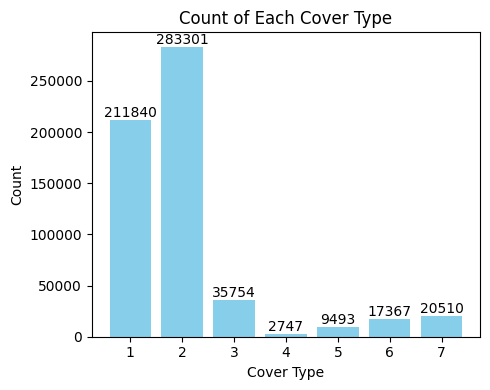

In [ ]:
# Count occurrences of each class
cover_type_counts = df['Cover_Type'].value_counts()

# Create a bar plot
plt.figure(figsize=(5,4))
bars = plt.bar(cover_type_counts.index, cover_type_counts.values, color='skyblue')

# Add counts above the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, int(yval),
             ha='center', va='bottom')

# Set labels and title
plt.xlabel('Cover Type')
plt.ylabel('Count')
plt.title('Count of Each Cover Type')
plt.xticks(cover_type_counts.index)  # Set x-ticks to be the cover type labels

# Show the plot
plt.tight_layout()
plt.show()

#Splitting Data

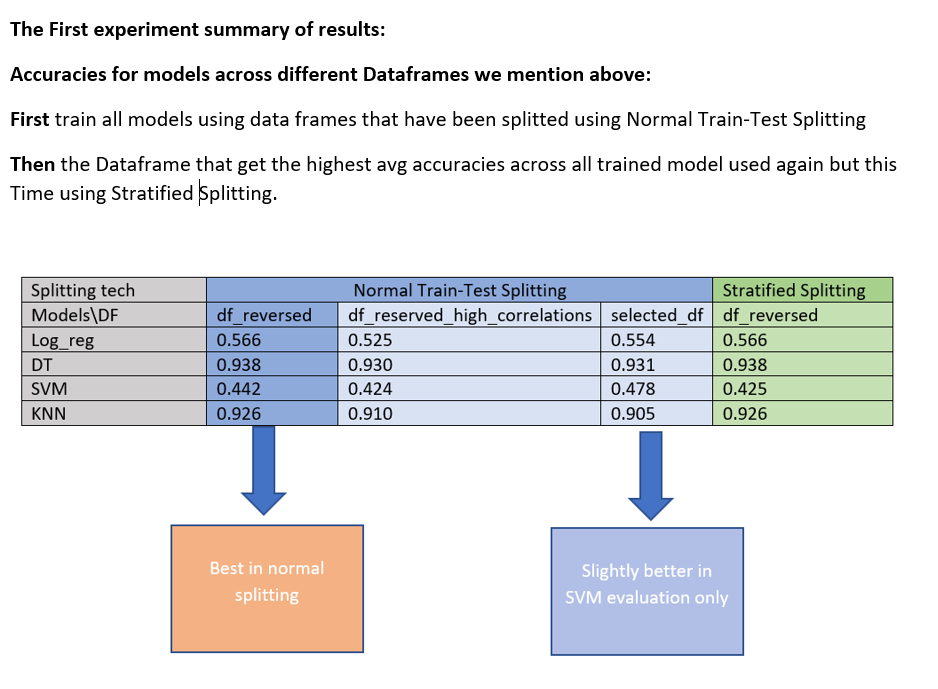

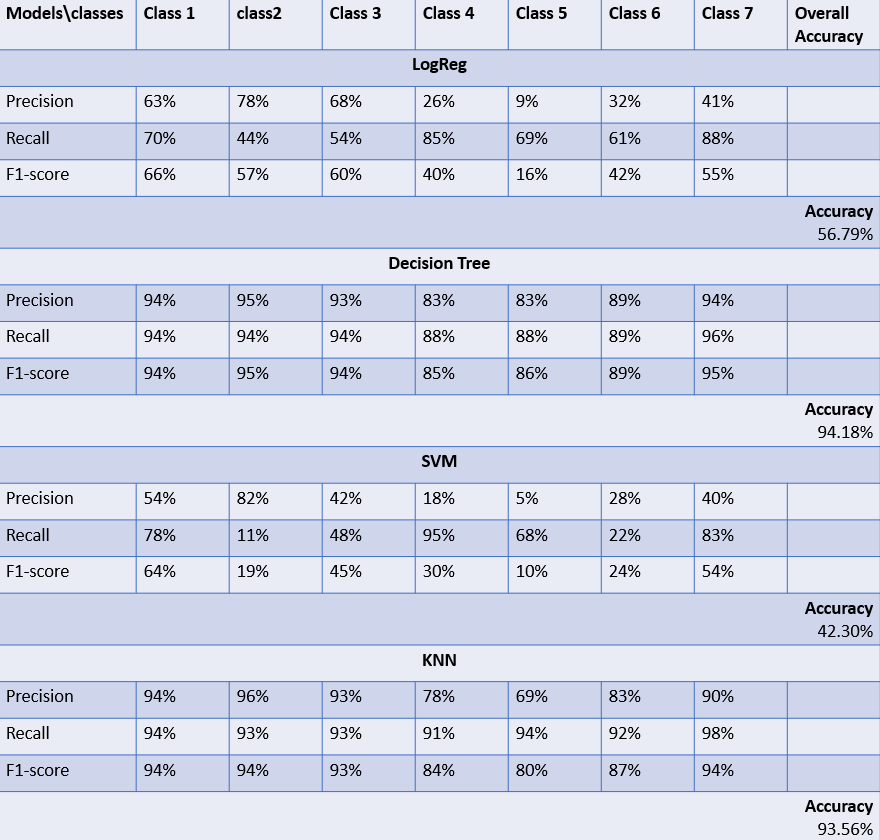

##Normal Train-Test Splitting df_reversed

1. df_reversed  
2. df_reserved_high_correlations
3. selected_df
----



There is alot of commented blocks of code that been done for expirement and no need to be run again
- first blocks of each section have the preperation of the specified dataframe
(this have not been commented it do run fast :) )
  - normal splitting
  - oversample SMOTE
  - Standarization

In [ ]:
# Normal train-test splitting for df_reversed
X_reversed = df_reversed.drop('Cover_Type', axis=1)
y_reversed = df_reversed['Cover_Type']

X_train_reversed, X_test_reversed, y_train_reversed, y_test_reversed = train_test_split(X_reversed, y_reversed, test_size=0.2, random_state=42)

print("df_reversed:")
print("X_train shape:", X_train_reversed.shape)
print("X_test shape:", X_test_reversed.shape)
print("y_train shape:", y_train_reversed.shape)
print("y_test shape:", y_test_reversed.shape)

df_reversed:
X_train shape: (464809, 14)
X_test shape: (116203, 14)
y_train shape: (464809,)
y_test shape: (116203,)


In [ ]:
#Handle imbalance (using SMOTE )
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_reversed, y_train_reversed)

# Output shapes after splitting and resampling
print("df_reversed:")
print("X_train shape:", X_train_resampled.shape)
print("X_test shape:", X_test_reversed.shape)
print("y_train shape:", y_train_resampled.shape)
print("y_test shape:", y_test_reversed.shape)

df_reversed:
X_train shape: (1587607, 14)
X_test shape: (116203, 14)
y_train shape: (1587607,)
y_test shape: (116203,)


In [ ]:
#Standardization
scaler = StandardScaler()
X_train_standardized = scaler.fit_transform(X_train_resampled)
X_test_standardized = scaler.transform(X_test_reversed)

# Output shapes after standardization
print("Standardized Data:")
print("X_train shape:", X_train_standardized.shape)
print("X_test shape:", X_test_standardized.shape)

Standardized Data:
X_train shape: (1587607, 14)
X_test shape: (116203, 14)


### LogisticRegresion  df_reversed_Normal_split

In [ ]:

# # Create the Logistic Regression model
# log_reg = LogisticRegression(random_state=42, max_iter=200)

# # Train the model with the standardized training data
# log_reg.fit(X_train_standardized, y_train_resampled)

# # Make predictions on the test data
# y_pred = log_reg.predict(X_test_standardized)

# # Evaluate the model
# accuracy = accuracy_score(y_test_reversed, y_pred)
# conf_matrix = confusion_matrix(y_test_reversed, y_pred)
# class_report = classification_report(y_test_reversed, y_pred)

# # Output the results
# print("Logistic Regression Model Performance:")
# print("Accuracy:", accuracy)
# print("Confusion Matrix:\n", conf_matrix)
# print("Classification Report:\n", class_report)

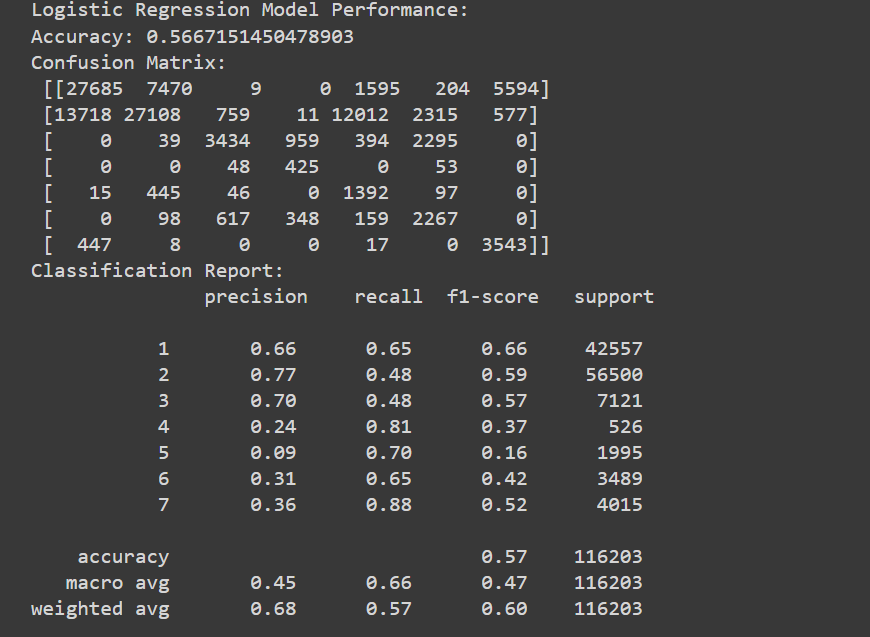

###DecisionTree df_reversed_Normal_split

In [ ]:
# # Create the Decision Tree model
# decision_tree = DecisionTreeClassifier(random_state=42)

# # Train the model with the standardized training data
# decision_tree.fit(X_train_standardized, y_train_resampled)

# # Make predictions on the test data
# y_pred_tree = decision_tree.predict(X_test_standardized)

# # Evaluate the model
# accuracy_tree = accuracy_score(y_test_reversed, y_pred_tree)
# conf_matrix_tree = confusion_matrix(y_test_reversed, y_pred_tree)
# class_report_tree = classification_report(y_test_reversed, y_pred_tree)

# # Output the results
# print("Decision Tree Model Performance:")
# print("Accuracy:", accuracy_tree)
# print("Confusion Matrix:\n", conf_matrix_tree)
# print("Classification Report:\n", class_report_tree)

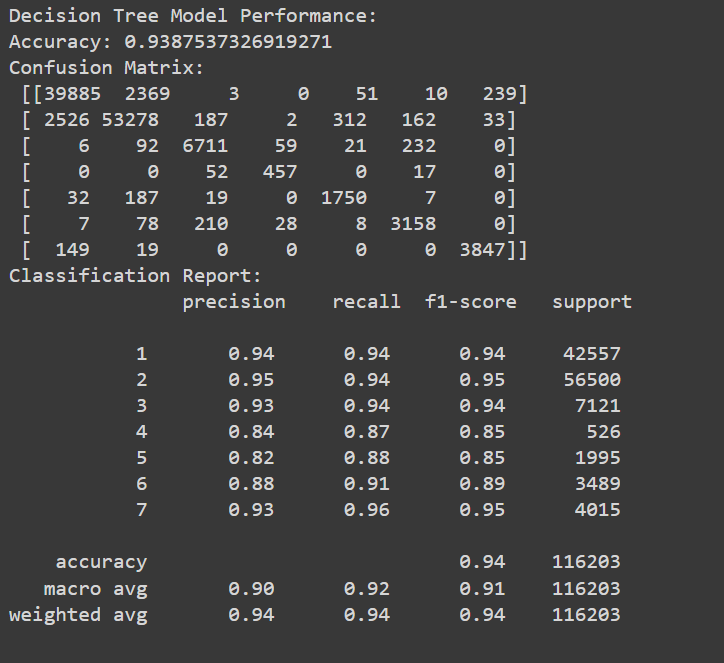

###SVM df_reversed_Normal_split

In [ ]:
# # Create the SVM model with SGD and hinge loss
# svm_model_fast = SGDClassifier(loss='hinge', random_state=42)

# # Train the model with the standardized training data
# svm_model_fast.fit(X_train_standardized, y_train_resampled)

# # Make predictions on the test data
# y_pred_svm_fast = svm_model_fast.predict(X_test_standardized)

# # Evaluate the model
# accuracy_svm_fast = accuracy_score(y_test_reversed, y_pred_svm_fast)
# conf_matrix_svm_fast = confusion_matrix(y_test_reversed, y_pred_svm_fast)
# class_report_svm_fast = classification_report(y_test_reversed, y_pred_svm_fast)

# # Output the results
# print("Fast SVM Model Performance:")
# print("Accuracy:", accuracy_svm_fast)
# print("Confusion Matrix:\n", conf_matrix_svm_fast)
# print("Classification Report:\n", class_report_svm_fast)

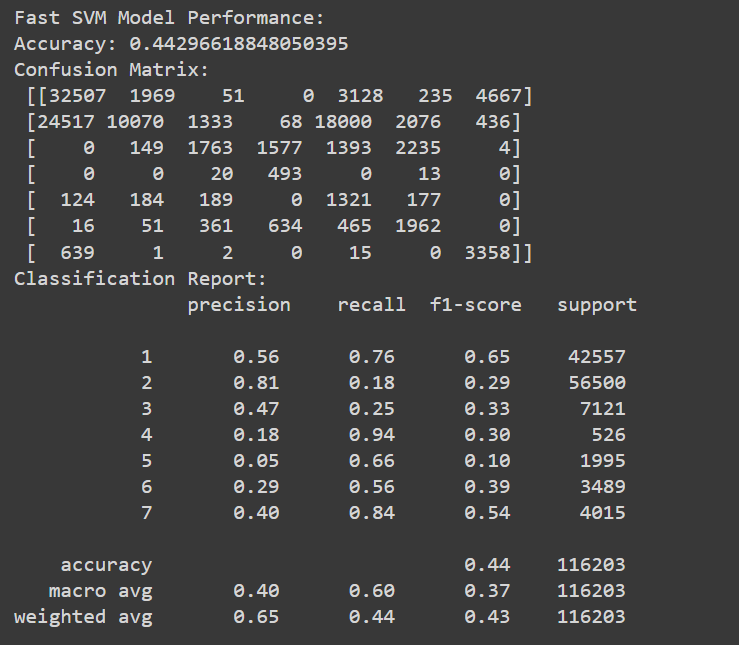

###KNN df_reversed_Normal_split

In [ ]:
# # Create the KNN model
# knn_model = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors as needed

# # Train the model with the standardized training data
# knn_model.fit(X_train_standardized, y_train_resampled)

# # Make predictions on the test data
# y_pred_knn = knn_model.predict(X_test_standardized)

# # Evaluate the model
# accuracy_knn = accuracy_score(y_test_reversed, y_pred_knn)
# conf_matrix_knn = confusion_matrix(y_test_reversed, y_pred_knn)
# class_report_knn = classification_report(y_test_reversed, y_pred_knn)

# # Output the results
# print("KNN Model Performance:")
# print("Accuracy:", accuracy_knn)
# print("Confusion Matrix:\n", conf_matrix_knn)
# print("Classification Report:\n", class_report_knn)

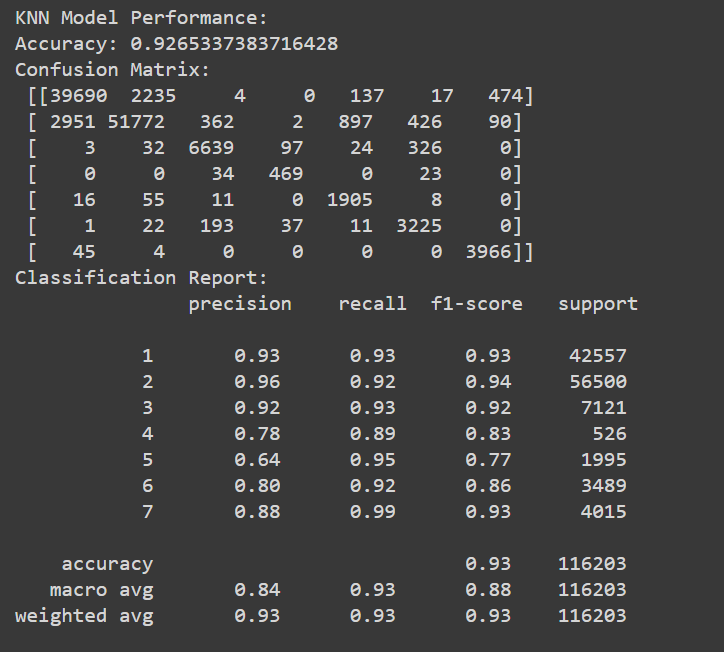

##Normal Train-Test Splitting df_reserved_high_correlations

In [ ]:
# Normal train-test splitting for df_reserved_high_correlations
X_high_correlations = df_reserved_high_correlations.drop('Cover_Type', axis=1)
y_high_correlations = df_reserved_high_correlations['Cover_Type']

X_train_high_correlations, X_test_high_correlations, y_train_high_correlations, y_test_high_correlations = train_test_split(X_high_correlations, y_high_correlations, test_size=0.2, random_state=42)

print("\ndf_reserved_high_correlations:")
print("X_train shape:", X_train_high_correlations.shape)
print("X_test shape:", X_test_high_correlations.shape)
print("y_train shape:", y_train_high_correlations.shape)
print("y_test shape:", y_test_high_correlations.shape)


df_reserved_high_correlations:
X_train shape: (464809, 8)
X_test shape: (116203, 8)
y_train shape: (464809,)
y_test shape: (116203,)


In [ ]:
# Handle imbalance (using SMOTE )
smote = SMOTE(random_state=42)
X_train_resampled_high_corr, y_train_resampled_high_corr = smote.fit_resample(X_train_high_correlations, y_train_high_correlations)

# Output shapes after resampling
print("After SMOTE:")
print("X_train_resampled shape:", X_train_resampled_high_corr.shape)
print("y_train_resampled shape:", y_train_resampled_high_corr.shape)

After SMOTE:
X_train_resampled shape: (1587607, 8)
y_train_resampled shape: (1587607,)


In [ ]:
# Standardization
scaler = StandardScaler()
X_train_standardized_high_corr = scaler.fit_transform(X_train_resampled_high_corr)
X_test_standardized_high_corr = scaler.transform(X_test_high_correlations)

# Output shapes after standardization
print("\nStandardized Data:")
print("X_train shape:", X_train_standardized_high_corr.shape)
print("X_test shape:", X_test_standardized_high_corr.shape)


Standardized Data:
X_train shape: (1587607, 8)
X_test shape: (116203, 8)


###LogisticRegression df_reserved_high_correlations_Normal

In [ ]:
# # Create the Logistic Regression model
# log_reg_high_corr = LogisticRegression(random_state=42, max_iter=250)

# # Train the model with the standardized training data
# log_reg_high_corr.fit(X_train_standardized_high_corr, y_train_resampled_high_corr)

# # Make predictions on the test data
# y_pred_high_corr = log_reg_high_corr.predict(X_test_standardized_high_corr)

# # Evaluate the model
# accuracy_high_corr = accuracy_score(y_test_high_correlations, y_pred_high_corr)
# conf_matrix_high_corr = confusion_matrix(y_test_high_correlations, y_pred_high_corr)
# class_report_high_corr = classification_report(y_test_high_correlations, y_pred_high_corr)

# # Output the results
# print("Logistic Regression Model Performance (High Correlations Dataset):")
# print("Accuracy:", accuracy_high_corr)
# print("Confusion Matrix:\n", conf_matrix_high_corr)
# print("Classification Report:\n", class_report_high_corr)

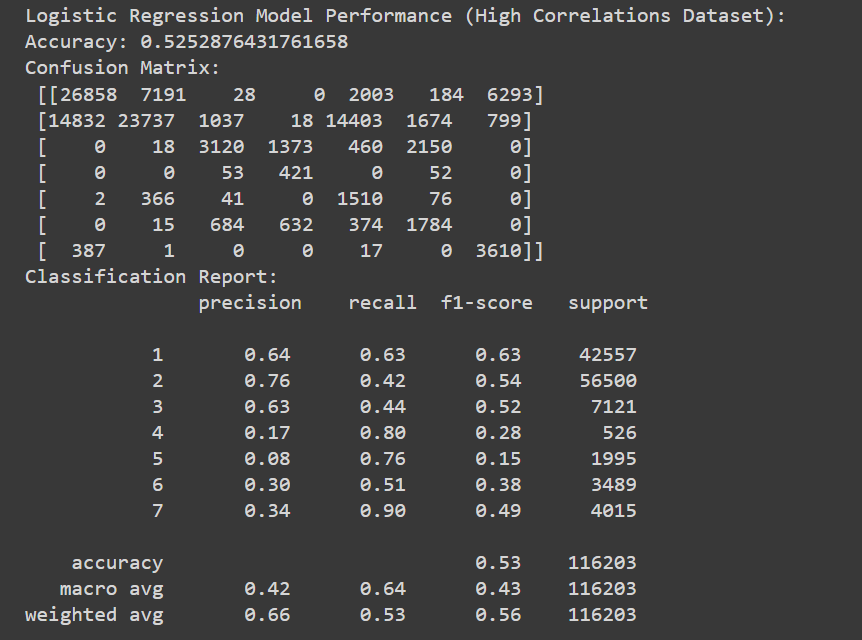

###DecisionTree df_reserved_high_correlations_Normal

In [ ]:
# # Create the Decision Tree model
# decision_tree_high_corr = DecisionTreeClassifier(random_state=42)

# # Train the model with the standardized training data
# decision_tree_high_corr.fit(X_train_standardized_high_corr, y_train_resampled_high_corr)

# # Make predictions on the test data
# y_pred_tree_high_corr = decision_tree_high_corr.predict(X_test_standardized_high_corr)

# # Evaluate the model
# accuracy_tree_high_corr = accuracy_score(y_test_high_correlations, y_pred_tree_high_corr)
# conf_matrix_tree_high_corr = confusion_matrix(y_test_high_correlations, y_pred_tree_high_corr)
# class_report_tree_high_corr = classification_report(y_test_high_correlations, y_pred_tree_high_corr)

# # Output the results
# print("Decision Tree Model Performance (High Correlations Dataset):")
# print("Accuracy:", accuracy_tree_high_corr)
# print("Confusion Matrix:\n", conf_matrix_tree_high_corr)
# print("Classification Report:\n", class_report_tree_high_corr)

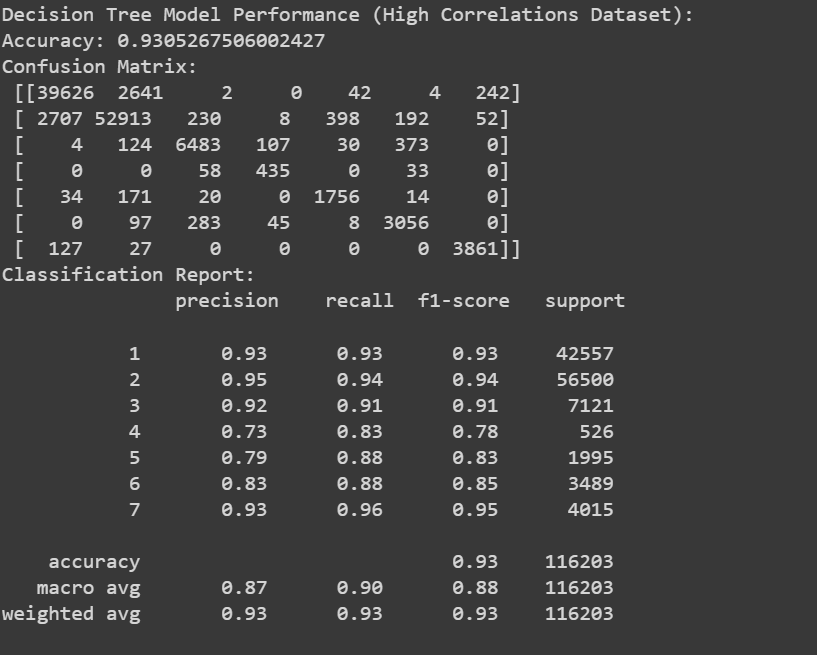

###SVM df_reserved_high_correlations_Normal

In [ ]:
# # Create the SVM model with SGD and hinge loss
# svm_model_fast = SGDClassifier(loss='hinge', random_state=42)

# # Train the model with the standardized training data
# svm_model_fast.fit(X_train_standardized_high_corr, y_train_resampled_high_corr)

# # Make predictions on the test data
# y_pred_svm_fast = svm_model_fast.predict(X_test_standardized_high_corr)

# # Evaluate the model
# accuracy_svm_fast = accuracy_score(y_test_high_correlations, y_pred_svm_fast)
# conf_matrix_svm_fast = confusion_matrix(y_test_high_correlations, y_pred_svm_fast)
# class_report_svm_fast = classification_report(y_test_high_correlations, y_pred_svm_fast)

# # Output the results
# print("Fast SVM Model Performance (High Correlations Dataset):")
# print("Accuracy:", accuracy_svm_fast)
# print("Confusion Matrix:\n", conf_matrix_svm_fast)
# print("Classification Report:\n", class_report_svm_fast)

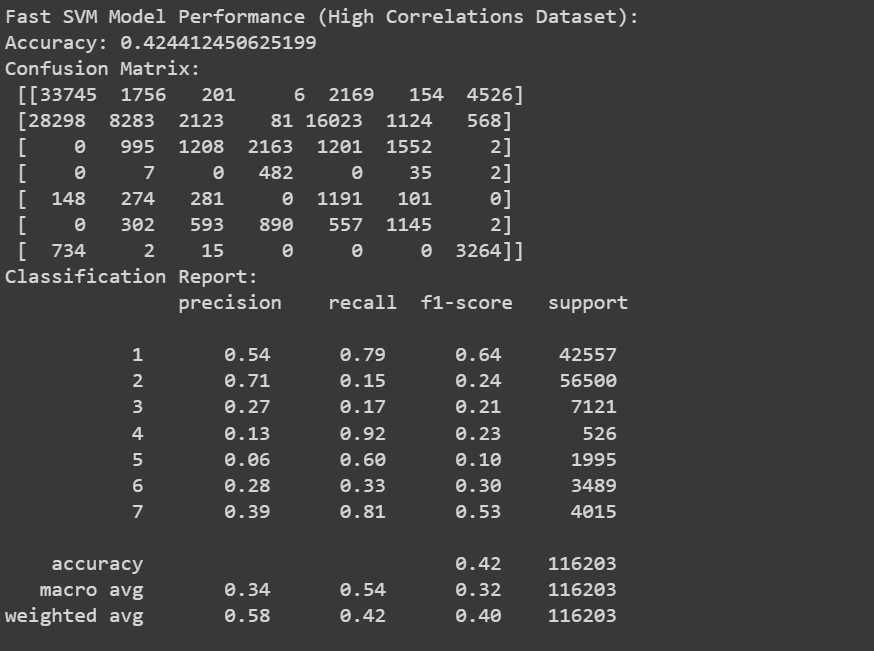

###KNN df_reserved_high_correlations_Normal

In [ ]:
# # Create the KNN model
# knn_model_high_corr = KNeighborsClassifier(n_neighbors=5)  # we could adjust n_neighbors as needed

# # Train the model with the standardized training data
# knn_model_high_corr.fit(X_train_standardized_high_corr, y_train_resampled_high_corr)

# # Make predictions on the test data
# y_pred_knn_high_corr = knn_model_high_corr.predict(X_test_standardized_high_corr)

# # Evaluate the model
# accuracy_knn_high_corr = accuracy_score(y_test_high_correlations, y_pred_knn_high_corr)
# conf_matrix_knn_high_corr = confusion_matrix(y_test_high_correlations, y_pred_knn_high_corr)
# class_report_knn_high_corr = classification_report(y_test_high_correlations, y_pred_knn_high_corr)

# # Output the results
# print("KNN Model Performance (High Correlations Dataset):")
# print("Accuracy:", accuracy_knn_high_corr)
# print("Confusion Matrix:\n", conf_matrix_knn_high_corr)
# print("Classification Report:\n", class_report_knn_high_corr)

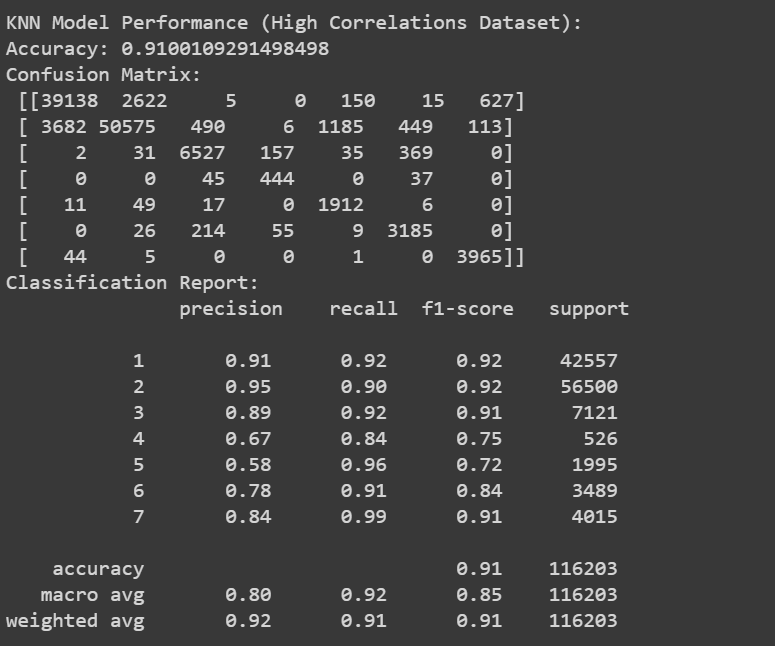

##Normal Train-Test Splitting selected_df

In [ ]:
# Normal train-test splitting for selected_df
X_selected = selected_df.drop('Cover_Type', axis=1)
y_selected = selected_df['Cover_Type']

X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(X_selected, y_selected, test_size=0.2, random_state=42)
# Print shapes for normal train-test split of selected_df
print("\nselected_df:")
print("X_train shape:", X_train_selected.shape)
print("X_test shape:", X_test_selected.shape)
print("y_train shape:", y_train_selected.shape)
print("y_test shape:", y_test_selected.shape)



selected_df:
X_train shape: (464809, 17)
X_test shape: (116203, 17)
y_train shape: (464809,)
y_test shape: (116203,)


In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled_selected, y_train_resampled_selected = smote.fit_resample(X_train_selected, y_train_selected)

# Output shapes after resampling
print("After SMOTE:")
print("X_train_resampled shape:", X_train_resampled_selected.shape)
print("y_train_resampled shape:", y_train_resampled_selected.shape)

After SMOTE:
X_train_resampled shape: (1587607, 17)
y_train_resampled shape: (1587607,)


In [ ]:
# Standardization
scaler = StandardScaler()
X_train_standardized_selected = scaler.fit_transform(X_train_resampled_selected)
X_test_standardized_selected = scaler.transform(X_test_selected)

# Output shapes after standardization
print("\nStandardized Data:")
print("X_train shape:", X_train_standardized_selected.shape)
print("X_test shape:", X_test_standardized_selected.shape)


Standardized Data:
X_train shape: (1587607, 17)
X_test shape: (116203, 17)


###LogisticRegression selected_df_Normal

In [ ]:
# # Create the Logistic Regression model
# log_reg_selected = LogisticRegression(random_state=42, max_iter=250)

# # Train the model with the standardized training data
# log_reg_selected.fit(X_train_standardized_selected, y_train_resampled_selected)

# # Make predictions on the test data
# y_pred_selected = log_reg_selected.predict(X_test_standardized_selected)

# # Evaluate the model
# accuracy_selected = accuracy_score(y_test_selected, y_pred_selected)
# conf_matrix_selected = confusion_matrix(y_test_selected, y_pred_selected)
# class_report_selected = classification_report(y_test_selected, y_pred_selected)

# # Output the results
# print("Logistic Regression Model Performance (Selected Dataset):")
# print("Accuracy:", accuracy_selected)
# print("Confusion Matrix:\n", conf_matrix_selected)
# print("Classification Report:\n", class_report_selected)

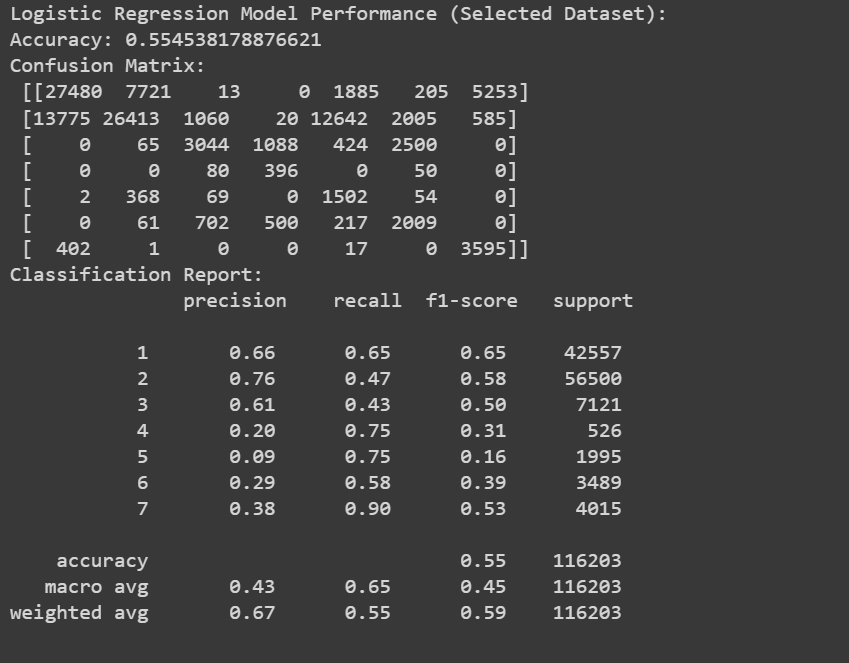

###DecisionTree selected_df_Normal

In [ ]:
# # Create the Decision Tree model
# decision_tree_selected = DecisionTreeClassifier(random_state=42)

# # Train the model with the standardized training data
# decision_tree_selected.fit(X_train_standardized_selected, y_train_resampled_selected)

# # Make predictions on the test data
# y_pred_tree_selected = decision_tree_selected.predict(X_test_standardized_selected)

# # Evaluate the model
# accuracy_tree_selected = accuracy_score(y_test_selected, y_pred_tree_selected)
# conf_matrix_tree_selected = confusion_matrix(y_test_selected, y_pred_tree_selected)
# class_report_tree_selected = classification_report(y_test_selected, y_pred_tree_selected)

# # Output the results
# print("Decision Tree Model Performance (Selected Dataset):")
# print("Accuracy:", accuracy_tree_selected)
# print("Confusion Matrix:\n", conf_matrix_tree_selected)
# print("Classification Report:\n", class_report_tree_selected)

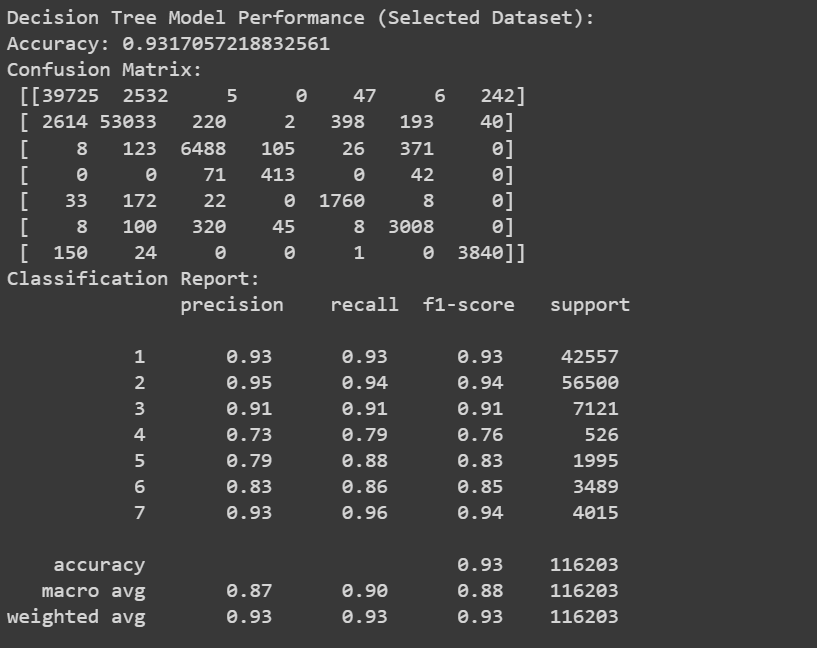

###SVM selected_df_Normal

In [ ]:
# # Create the fast SVM model using SGD with hinge loss
# svm_model_fast = SGDClassifier(loss='hinge', random_state=42)

# # Train the model with the standardized training data
# svm_model_fast.fit(X_train_standardized_selected, y_train_resampled_selected)

# # Make predictions on the test data
# y_pred_svm_fast = svm_model_fast.predict(X_test_standardized_selected)

# # Evaluate the model
# accuracy_svm_fast = accuracy_score(y_test_selected, y_pred_svm_fast)
# conf_matrix_svm_fast = confusion_matrix(y_test_selected, y_pred_svm_fast)
# class_report_svm_fast = classification_report(y_test_selected, y_pred_svm_fast)

# # Output the results
# print("Fast SVM Model Performance (Selected Dataset):")
# print("Accuracy:", accuracy_svm_fast)
# print("Confusion Matrix:\n", conf_matrix_svm_fast)
# print("Classification Report:\n", class_report_svm_fast)

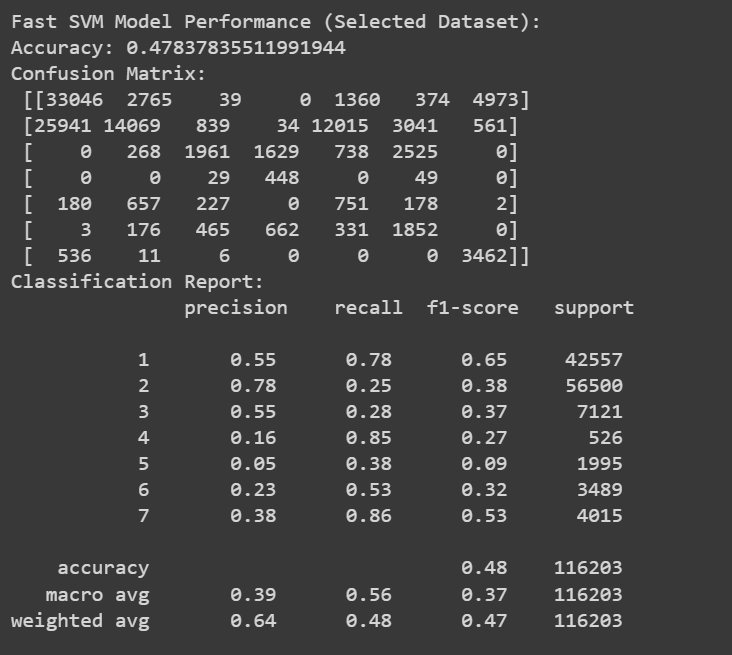

###KNN selected_df_Normal

In [ ]:
# # Create the KNN model using KD-Tree   3 min time complexity!!
# knn_model_selected = KNeighborsClassifier(n_neighbors=5, algorithm='kd_tree')

# # Train the model with the standardized training data
# knn_model_selected.fit(X_train_standardized_selected, y_train_resampled_selected)

# # Make predictions on the test data
# y_pred_knn_selected = knn_model_selected.predict(X_test_standardized_selected)

# # Evaluate the model
# accuracy_knn_selected = accuracy_score(y_test_selected, y_pred_knn_selected)
# conf_matrix_knn_selected = confusion_matrix(y_test_selected, y_pred_knn_selected)
# class_report_knn_selected = classification_report(y_test_selected, y_pred_knn_selected)

# # Output the results
# print("KNN Model Performance (Selected Dataset):")
# print("Accuracy:", accuracy_knn_selected)
# print("Confusion Matrix:\n", conf_matrix_knn_selected)
# print("Classification Report:\n", class_report_knn_selected)

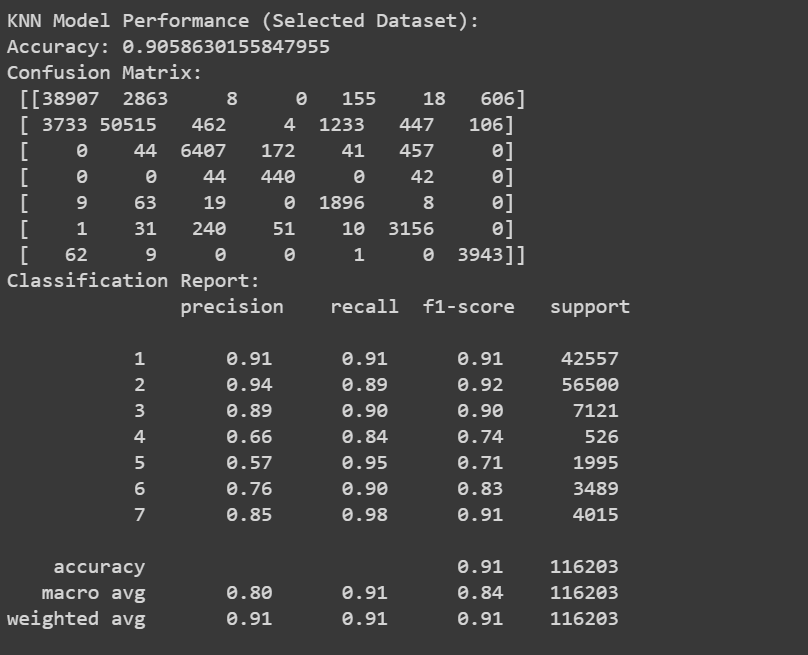

##Stratified Train-Test Splitting

Selected Split and dataframe will be this

`Stradified split is done only on df_reversed because it do best when we use normal splitting . How this df will perform when using Stratified split instead of normal spilt`


In [ ]:
# Stratified train-test splitting for df_reversed
X_reversed = df_reversed.drop('Cover_Type', axis=1)
y_reversed = df_reversed['Cover_Type']


X_train_reversed_stratified, X_test_reversed_stratified, y_train_reversed_stratified, y_test_reversed_stratified = train_test_split(X_reversed, y_reversed, test_size=0.2, random_state=42, stratify=y_reversed)

print("\ndf_reversed (Stratified):")
print("X_train shape:", X_train_reversed_stratified.shape)
print("X_test shape:", X_test_reversed_stratified.shape)
print("y_train shape:", y_train_reversed_stratified.shape)
print("y_test shape:", y_test_reversed_stratified.shape)


df_reversed (Stratified):
X_train shape: (464809, 14)
X_test shape: (116203, 14)
y_train shape: (464809,)
y_test shape: (116203,)


In [ ]:
# Handle imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_resampled_reversed, y_train_resampled_reversed = smote.fit_resample(X_train_reversed_stratified, y_train_reversed_stratified)

# Output shapes after resampling
print("After SMOTE:")
print("X_train_resampled shape:", X_train_resampled_reversed.shape)
print("y_train_resampled shape:", y_train_resampled_reversed.shape)

After SMOTE:
X_train_resampled shape: (1586480, 14)
y_train_resampled shape: (1586480,)


In [ ]:
# Standardization
scaler = StandardScaler()
X_train_standardized_reversed = scaler.fit_transform(X_train_resampled_reversed)
X_test_standardized_reversed = scaler.transform(X_test_reversed_stratified)

# Output shapes after standardization
print("\nStandardized Data:")
print("X_train shape:", X_train_standardized_reversed.shape)
print("X_test shape:", X_test_standardized_reversed.shape)


Standardized Data:
X_train shape: (1586480, 14)
X_test shape: (116203, 14)


###LogisticRegression df_reversed_Stratified

In [ ]:
# Create the Logistic Regression model
log_reg_reversed = LogisticRegression(random_state=42, max_iter=250)

# Train the model with the standardized training data
log_reg_reversed.fit(X_train_standardized_reversed, y_train_resampled_reversed)

# Make predictions on the test data
y_pred_reversed = log_reg_reversed.predict(X_test_standardized_reversed)

# Evaluate the model
accuracy_reversed = accuracy_score(y_test_reversed_stratified, y_pred_reversed)
conf_matrix_reversed = confusion_matrix(y_test_reversed_stratified, y_pred_reversed)
class_report_reversed = classification_report(y_test_reversed_stratified, y_pred_reversed)

# Output the results
print("Logistic Regression Model Performance (Reversed Dataset):")
print("Accuracy:", accuracy_reversed)
print("Confusion Matrix:\n", conf_matrix_reversed)
print("Classification Report:\n", class_report_reversed)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Model Performance (Reversed Dataset):
Accuracy: 0.5667839900863144
Confusion Matrix:
 [[27454  7563    11     0  1692   186  5462]
 [13720 27163   838    10 11985  2350   595]
 [    0    29  3467  1001   408  2246     0]
 [    0     0    30   471     0    48     0]
 [    7   408    44     0  1366    74     0]
 [    0    81   609   338   158  2287     0]
 [  417    12     0     0    19     0  3654]]
Classification Report:
               precision    recall  f1-score   support

           1       0.66      0.65      0.65     42368
           2       0.77      0.48      0.59     56661
           3       0.69      0.48      0.57      7151
           4       0.26      0.86      0.40       549
           5       0.09      0.72      0.16      1899
           6       0.32      0.66      0.43      3473
           7       0.38      0.89      0.53      4102

    accuracy                           0.57    116203
   macro avg       0.45      0.68      0.48    116203
weighted avg

###DecisionTree df_reversed_Stratified

In [ ]:
# Create the Decision Tree model
decision_tree_reversed = DecisionTreeClassifier(random_state=42)

# Train the model with the standardized training data
decision_tree_reversed.fit(X_train_standardized_reversed, y_train_resampled_reversed)

# Make predictions on the test data
y_pred_tree_reversed = decision_tree_reversed.predict(X_test_standardized_reversed)

# Evaluate the model
accuracy_tree_reversed = accuracy_score(y_test_reversed_stratified, y_pred_tree_reversed)
conf_matrix_tree_reversed = confusion_matrix(y_test_reversed_stratified, y_pred_tree_reversed)
class_report_tree_reversed = classification_report(y_test_reversed_stratified, y_pred_tree_reversed)

# Output the results
print("Decision Tree Model Performance (Reversed Dataset):")
print("Accuracy:", accuracy_tree_reversed)
print("Confusion Matrix:\n", conf_matrix_tree_reversed)
print("Classification Report:\n", class_report_tree_reversed)

Decision Tree Model Performance (Reversed Dataset):
Accuracy: 0.9381427329759129
Confusion Matrix:
 [[39801  2287     9     0    37     8   226]
 [ 2561 53340   222     3   305   188    42]
 [    2   132  6726    55    13   223     0]
 [    0     1    57   473     0    18     0]
 [   23   176    18     0  1673     9     0]
 [    5   103   260    18     6  3081     0]
 [  156    25     0     0     0     0  3921]]
Classification Report:
               precision    recall  f1-score   support

           1       0.94      0.94      0.94     42368
           2       0.95      0.94      0.95     56661
           3       0.92      0.94      0.93      7151
           4       0.86      0.86      0.86       549
           5       0.82      0.88      0.85      1899
           6       0.87      0.89      0.88      3473
           7       0.94      0.96      0.95      4102

    accuracy                           0.94    116203
   macro avg       0.90      0.92      0.91    116203
weighted avg      

###SVM df_reversed_Stratified

In [ ]:
# Create the fast SVM model using SGD with hinge loss
svm_model_fast_reversed = SGDClassifier(loss='hinge', random_state=42)

# Train the model with the standardized training data
svm_model_fast_reversed.fit(X_train_standardized_reversed, y_train_resampled_reversed)

# Make predictions on the test data
y_pred_svm_fast_reversed = svm_model_fast_reversed.predict(X_test_standardized_reversed)

# Evaluate the model
accuracy_svm_fast_reversed = accuracy_score(y_test_reversed_stratified, y_pred_svm_fast_reversed)
conf_matrix_svm_fast_reversed = confusion_matrix(y_test_reversed_stratified, y_pred_svm_fast_reversed)
class_report_svm_fast_reversed = classification_report(y_test_reversed_stratified, y_pred_svm_fast_reversed)

# Output the results
print("Fast SVM Model Performance (Reversed Dataset):")
print("Accuracy:", accuracy_svm_fast_reversed)
print("Confusion Matrix:\n", conf_matrix_svm_fast_reversed)
print("Classification Report:\n", class_report_svm_fast_reversed)

Fast SVM Model Performance (Reversed Dataset):
Accuracy: 0.42510090100944037
Confusion Matrix:
 [[33812  1079    67     0  2807   161  4442]
 [28029  6643  1365    63 18208  1933   420]
 [    0   245  2049  1617  1453  1786     1]
 [    0     0    10   525     0    14     0]
 [  129   165   162     0  1343   100     0]
 [    4    99   640   632   480  1618     0]
 [  674     2     1     0    17     0  3408]]
Classification Report:
               precision    recall  f1-score   support

           1       0.54      0.80      0.64     42368
           2       0.81      0.12      0.20     56661
           3       0.48      0.29      0.36      7151
           4       0.19      0.96      0.31       549
           5       0.06      0.71      0.10      1899
           6       0.29      0.47      0.36      3473
           7       0.41      0.83      0.55      4102

    accuracy                           0.43    116203
   macro avg       0.39      0.59      0.36    116203
weighted avg       0.6

###KNN df_reversed_Stratified

In [ ]:
# Create the KNN model
knn_model_reversed = KNeighborsClassifier(n_neighbors=5, algorithm='auto')

# Train the model with the standardized training data
knn_model_reversed.fit(X_train_standardized_reversed, y_train_resampled_reversed)

# Make predictions on the test data
y_pred_knn_reversed = knn_model_reversed.predict(X_test_standardized_reversed)

# Evaluate the model
accuracy_knn_reversed = accuracy_score(y_test_reversed_stratified, y_pred_knn_reversed)
conf_matrix_knn_reversed = confusion_matrix(y_test_reversed_stratified, y_pred_knn_reversed)
class_report_knn_reversed = classification_report(y_test_reversed_stratified, y_pred_knn_reversed)

# Output the results
print("KNN Model Performance (Reversed Dataset):")
print("Accuracy:", accuracy_knn_reversed)
print("Confusion Matrix:\n", conf_matrix_knn_reversed)
print("Classification Report:\n", class_report_knn_reversed)

KNN Model Performance (Reversed Dataset):
Accuracy: 0.9268091185253393
Confusion Matrix:
 [[39504  2219     9     0   116    23   497]
 [ 2942 51991   355     2   843   436    92]
 [    2    38  6665   111    19   316     0]
 [    0     0    42   487     0    20     0]
 [   11    50    13     0  1811    14     0]
 [    2    26   199    37     7  3202     0]
 [   54    10     0     0     0     0  4038]]
Classification Report:
               precision    recall  f1-score   support

           1       0.93      0.93      0.93     42368
           2       0.96      0.92      0.94     56661
           3       0.92      0.93      0.92      7151
           4       0.76      0.89      0.82       549
           5       0.65      0.95      0.77      1899
           6       0.80      0.92      0.86      3473
           7       0.87      0.98      0.93      4102

    accuracy                           0.93    116203
   macro avg       0.84      0.93      0.88    116203
weighted avg       0.93     

#Hyperparameter Tuning



**Methid Used:**
First use RandomizedSearchCV on Undersampled Data . After getting the best parameters from the undersampled data . Apply oversampling (SMOTE) on the original data set.

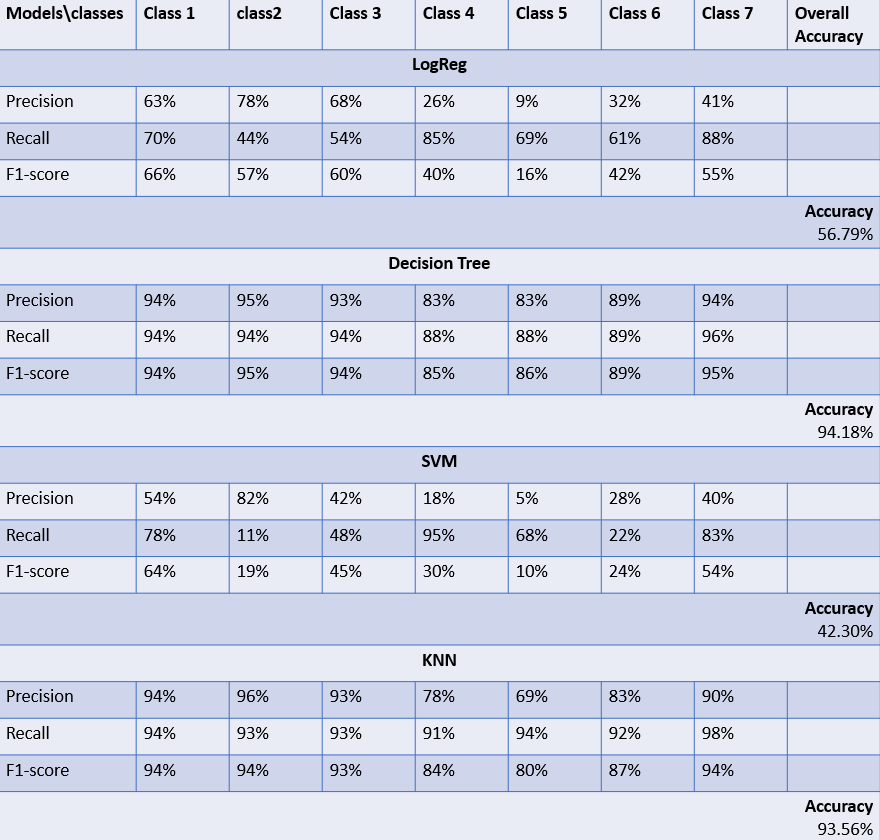

##Stratified Train-Test Splitting

Stratified Train-Test Splitting will be the
Selected Split and dataframe df_reversed will be the final selected df

`Stradified split is done only on df_reversed because it do best when we use normal splitting . How this df will perform when using Stratified split instead of normal spilt`


In [ ]:
X_reversed = df_reversed.drop('Cover_Type', axis=1)
y_reversed = df_reversed['Cover_Type']
# Split the data into 80% training and 20% test sets
X_train_val, X_test_reversed, y_train_val, y_test_reversed = train_test_split(
    X_reversed, y_reversed, test_size=0.2, random_state=42, stratify=y_reversed
)

#  Further split the 80% training data into 70% training and 10% validation sets
X_train_reversed, X_val_reversed, y_train_reversed, y_val_reversed = train_test_split(
    X_train_val, y_train_val, test_size=0.125, random_state=42, stratify=y_train_val
)

# Display the shape of the resulting datasets
print("\nFinal Train-Validation-Test Split Results:")
print("Training set shape:", X_train_reversed.shape)
print("Validation set shape:", X_val_reversed.shape)
print("Test set shape:", X_test_reversed.shape)
print("y_train shape:", y_train_reversed.shape)
print("y_val shape:", y_val_reversed.shape)
print("y_test shape:", y_test_reversed.shape)


# 80% Training + 20% Test: We first reserve 20% of the data for the test set, which will not be touched until the very end when we perform the final model evaluation.
# 70% Training + 10% Validation: From the initial 80% training data, we further split off 10% as the validation set, resulting in a 70% training, 10% validation, and 20% test split overall.


Final Train-Validation-Test Split Results:
Training set shape: (406707, 14)
Validation set shape: (58102, 14)
Test set shape: (116203, 14)
y_train shape: (406707,)
y_val shape: (58102,)
y_test shape: (116203,)


In [ ]:
#Undersample the original training data
X_train_reversed_final = X_train_reversed
y_train_reversed_final = y_train_reversed

under_sampler = RandomUnderSampler(random_state=42)
X_train_undersampled, y_train_undersampled = under_sampler.fit_resample(X_train_reversed_final, y_train_reversed_final)

# Scale the undersampled data
scaler = StandardScaler()
X_train_undersampled_scaled = scaler.fit_transform(X_train_undersampled)

In [ ]:
print("X_train_undersampled shape:", X_train_undersampled.shape)
print("y_train_undersampled shape:", y_train_undersampled.shape)

X_train_undersampled shape: (13461, 14)
y_train_undersampled shape: (13461,)


In [ ]:
smote = SMOTE(random_state=42)
X_train_oversampled, y_train_oversampled = smote.fit_resample(X_train_reversed_final, y_train_reversed_final)

# Scale the oversampled data
X_train_oversampled_scaled = scaler.fit_transform(X_train_oversampled)  # Refit scaler to the new oversampled data
X_val_scaled = scaler.transform(X_val_reversed)   # Keep validation set scaled
X_test_scaled = scaler.transform(X_test_reversed) # Keep test set scaled

###LogisticRegression df_reversed_Stratified

Accuracy of the model across best parameters without validate set:

1st
 0.6811962239052154 =>
Best Hyperparameters from RandomizedSearchCV: {'solver': 'saga', 'penalty': 'l2', 'max_iter': 100, 'class_weight': 'balanced', 'C': 19306.977288832535}

2nd
0.6822052466155382 =>
Best Hyperparameters from RandomizedSearchCV: {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 200, 'class_weight': 'balanced', 'C': 162.37767391887175}

3rd
0.6823111410529034 =>
Best Hyperparameters from RandomizedSearchCV: {'solver': 'newton-cg', 'penalty': 'l2', 'max_iter': 500, 'class_weight': 'balanced', 'C': 2976.3514416313133}

4th
0.6823111410529034 =>
Best Hyperparameters from RandomizedSearchCV: {'solver': 'newton-cg', 'penalty': 'l2', 'max_iter': 1500, 'class_weight': None, 'C': 162.37767391887175}

5th
 3h 2m 10s Here i increase the parameters and number of values in the random search
 The previous was way more better because it took approx less than 10 min running

 0.6845313944229938 =>
Best Hyperparameters from RandomizedSearchCV: {'solver': 'lbfgs', 'penalty': 'l2', 'multi_class': 'multinomial', 'max_iter': 3000, 'class_weight': 'balanced', 'C': 1438.449888287663}

final 1 min time compelexity
 0.6823182006820611 => Best Hyperparameters from RandomizedSearchCV: {'solver': 'newton-cg', 'penalty': 'l2', 'max_iter': 100, 'class_weight': 'balanced', 'C': 2000.0000000000002}





In [ ]:

#  Hyperparameter Tuning with RandomizedSearchCV on Undersampled Data
log_reg = LogisticRegression(random_state=42)

param_grid = {
    'C': np.logspace(0, 6, 20),  # Higher range of C values
    'penalty': ['elasticnet', 'l1', 'l2', None],  # Note: choice of penalty depends on solverlinear' and 'newton-cholesky' for small datasets, binary classification
    'solver': ['lbfgs', 'newton-cg', 'sag', 'saga', 'newton-cholesky'],  # Default='lbfgs', 'lib
    'max_iter': [3000],  # Increased range for max iterations
    'class_weight': [None, 'balanced'],  # Handling class imbalance, default=None
    'multi_class': ['auto', 'ovr', 'multinomial'],  # Default='auto'
    'tol':[2.0,10.0]
}


random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_grid,
    n_iter=1000,
    cv=5,
    random_state=42,
    n_jobs=-1,
    error_score=np.nan
)

# Train the model with the undersampled and standardized training data
random_search.fit(X_train_undersampled_scaled, y_train_undersampled)

# Get the best parameters found by RandomizedSearchCV
best_params = random_search.best_params_
print("\nBest Hyperparameters from RandomizedSearchCV for LogisticRegression:", best_params)


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
2460 fits failed out of a total of 5000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
280 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1194, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File


Best Hyperparameters from RandomizedSearchCV for LogisticRegression: {'tol': 2.0, 'solver': 'saga', 'penalty': 'l1', 'multi_class': 'auto', 'max_iter': 3000, 'class_weight': 'balanced', 'C': 2.0691380811147897}


In [ ]:

# Train the Model with the Best Parameters Found from RandomizedSearchCV
best_log_reg = LogisticRegression(**best_params, random_state=42)

# Train the model using the oversampled data
best_log_reg.fit(X_train_oversampled_scaled , y_train_oversampled)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=2.0691380811147897, class_weight='balanced', max_iter=3000,
                   multi_class='auto', penalty='l1', random_state=42,
                   solver='saga', tol=2.0)

In [ ]:

# Evaluate the model on the validation set
y_val_pred_log_reg = best_log_reg.predict(X_val_scaled)
val_accuracy_log_reg = accuracy_score(y_val_reversed, y_val_pred_log_reg)
val_conf_matrix_log_reg = confusion_matrix(y_val_reversed, y_val_pred_log_reg)
val_class_report_log_reg = classification_report(y_val_reversed, y_val_pred_log_reg)

print("\nLogistic Regression Validation Set Evaluation on SMOTE-Oversampled Data:")
print("Accuracy:", val_accuracy_log_reg)
print("Confusion Matrix:\n", val_conf_matrix_log_reg)
print("Classification Report:\n", val_class_report_log_reg)

# Evaluate the model on the test set
y_test_pred_log_reg = best_log_reg.predict(X_test_scaled)
test_accuracy_log_reg = accuracy_score(y_test_reversed, y_test_pred_log_reg)
test_conf_matrix_log_reg = confusion_matrix(y_test_reversed, y_test_pred_log_reg)
test_class_report_log_reg = classification_report(y_test_reversed, y_test_pred_log_reg)

print("\nLogistic Regression Test Set Evaluation on SMOTE-Oversampled Data:")
print("Accuracy:", test_accuracy_log_reg)
print("Confusion Matrix:\n", test_conf_matrix_log_reg)
print("Classification Report:\n", test_class_report_log_reg)


Logistic Regression Validation Set Evaluation on SMOTE-Oversampled Data:
Accuracy: 0.5655399125675536
Confusion Matrix:
 [[14681  3186     3     0   728   124  2462]
 [ 8272 12535   460     6  5615  1203   239]
 [    0    12  1916   503   146   999     0]
 [    0     0    18   231     0    26     0]
 [    8   223    33     0   648    37     0]
 [    0    42   431   157    66  1041     0]
 [  240     0     0     0     4     0  1807]]
Classification Report:
               precision    recall  f1-score   support

           1       0.63      0.69      0.66     21184
           2       0.78      0.44      0.57     28330
           3       0.67      0.54      0.60      3576
           4       0.26      0.84      0.39       275
           5       0.09      0.68      0.16       949
           6       0.30      0.60      0.40      1737
           7       0.40      0.88      0.55      2051

    accuracy                           0.57     58102
   macro avg       0.45      0.67      0.48     58

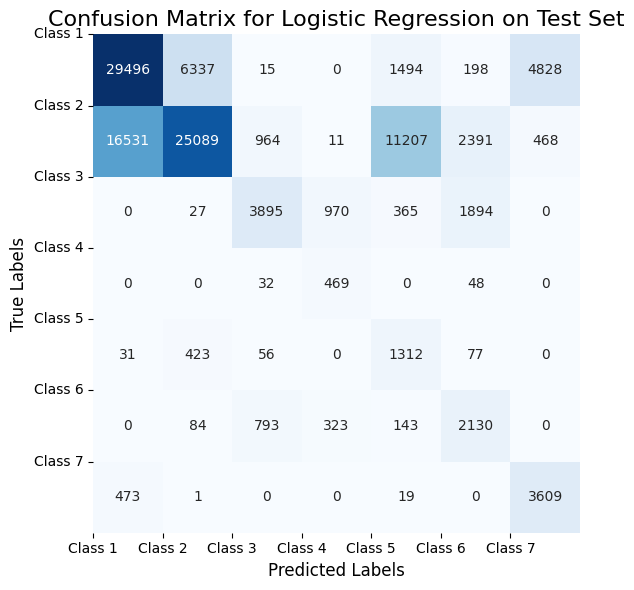

In [ ]:
# Plot the confusion matrix
plt.figure(figsize=(6,6))
sns.heatmap(test_conf_matrix_log_reg, annot=True, fmt='g', cmap='Blues', cbar=False)

# Add labels, title, and axes ticks
plt.title('Confusion Matrix for Logistic Regression on Test Set', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3, 4, 5, 6], labels=['Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6', 'Class 7'])
plt.yticks(ticks=[0, 1, 2, 3, 4, 5, 6], labels=['Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6', 'Class 7'], rotation=0)

# Display the confusion matrix
plt.tight_layout()
plt.show()

###DecisionTree df_reversed_Stratified

In [ ]:
#Scale the Undersampled Data
scaler = StandardScaler()
X_train_undersampled_scaled = scaler.fit_transform(X_train_undersampled)

In [ ]:
#Initialize the Decision Tree Classifier
DT = DecisionTreeClassifier(random_state=42)

param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'], #default=”gini”  # Higher range of C values
    'splitter': ['best', 'random'],   # default 'best'
    'max_depth': [ 5, 10, 20, 30, 50, 100],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 10],
    'max_features': [None, 'sqrt', 'log2'],
    'max_leaf_nodes': [None, 10, 20, 50, 100],
}

# Setup RandomizedSearchCV with error score handling
random_search = RandomizedSearchCV(
    DT,
    param_distributions=param_grid,
    n_iter=250,
    cv=5,        # Cross-validation folds
    random_state=42,
    n_jobs=-1,
    verbose=1,   # Enables progress updates
    error_score=np.nan  # Replace failed fits with np.nan
)

# Train the model with the undersampled and scaled training data
random_search.fit(X_train_undersampled_scaled, y_train_undersampled)

# Print the best hyperparameters found by RandomizedSearchCV
print("\nBest Hyperparameters from RandomizedSearchCV:", random_search.best_params_)

Fitting 5 folds for each of 250 candidates, totalling 1250 fits

Best Hyperparameters from RandomizedSearchCV: {'splitter': 'best', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_leaf_nodes': None, 'max_features': None, 'max_depth': 100, 'criterion': 'log_loss'}


In [ ]:
# Train the Model with the Best Parameters Found from RandomizedSearchCV
# Use the best parameters obtained from RandomizedSearchCV
best_params = random_search.best_params_  # Assuming random_search has already been run

# Initialize the Decision Tree Classifier with the best parameters
best_DT = DecisionTreeClassifier(**best_params, random_state=42)

# Train the model using the oversampled data
best_DT.fit(X_train_oversampled, y_train_oversampled)

DecisionTreeClassifier(criterion='log_loss', max_depth=100, min_samples_split=5,
                       random_state=42)

In [ ]:
#  Evaluate the Model on the Validation Set
y_val_pred = best_DT.predict(X_val_reversed)
val_accuracy = accuracy_score(y_val_reversed, y_val_pred)
val_conf_matrix = confusion_matrix(y_val_reversed, y_val_pred)
val_class_report = classification_report(y_val_reversed, y_val_pred)

print("\nValidation Set Evaluation:")
print("Accuracy:", val_accuracy)
print("Confusion Matrix:\n", val_conf_matrix)
print("Classification Report:\n", val_class_report)

# Step 4: Evaluate the Model on the Test Set
y_test_pred = best_DT.predict(X_test_reversed)
test_accuracy = accuracy_score(y_test_reversed, y_test_pred)
test_conf_matrix = confusion_matrix(y_test_reversed, y_test_pred)
test_class_report = classification_report(y_test_reversed, y_test_pred)

print("\nTest Set Evaluation:")
print("Accuracy:", test_accuracy)
print("Confusion Matrix:\n", test_conf_matrix)
print("Classification Report:\n", test_class_report)


Validation Set Evaluation:
Accuracy: 0.9423771987194933
Confusion Matrix:
 [[20002  1061     1     0    18     3    99]
 [ 1152 26808    99     0   178    79    14]
 [    0    59  3341    43    11   122     0]
 [    0     0    23   245     0     7     0]
 [   16    93     6     0   829     4     1]
 [    1    34   121    14     4  1563     0]
 [   77     7     0     0     1     0  1966]]
Classification Report:
               precision    recall  f1-score   support

           1       0.94      0.94      0.94     21184
           2       0.96      0.95      0.95     28330
           3       0.93      0.93      0.93      3576
           4       0.81      0.89      0.85       275
           5       0.80      0.87      0.83       949
           6       0.88      0.90      0.89      1737
           7       0.95      0.96      0.95      2051

    accuracy                           0.94     58102
   macro avg       0.89      0.92      0.91     58102
weighted avg       0.94      0.94      0.9

 0.805653956140541 => Best Hyperparameters from RandomizedSearchCV: {'splitter': 'best', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_leaf_nodes': None, 'max_features': None, 'max_depth': 100, 'criterion': 'log_loss'}

 Note the results was always between 78 to 81 until applying test validate train split


  0.9376613541702523=>Best Hyperparameters from RandomizedSearchCV: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}

   0.945303087673402 =>Best Hyperparameters from RandomizedSearchCV: {'splitter': 'best', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_leaf_nodes': None, 'max_features': None, 'max_depth': 100, 'criterion': 'log_loss'}

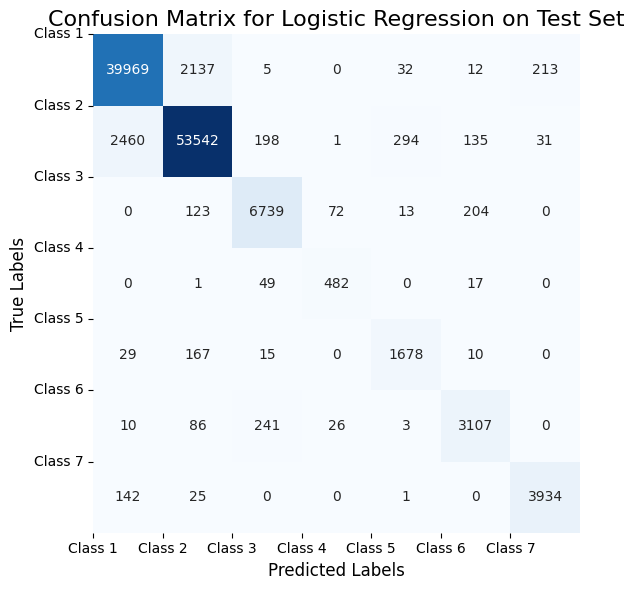

In [ ]:
# Plot the test confusion matrix
plt.figure(figsize=(6,6))
sns.heatmap(test_conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

# Add labels, title, and axes ticks
plt.title('Confusion Matrix for Logistic Regression on Test Set', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3, 4, 5, 6], labels=['Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6', 'Class 7'])
plt.yticks(ticks=[0, 1, 2, 3, 4, 5, 6], labels=['Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6', 'Class 7'], rotation=0)

# Display the confusion matrix
plt.tight_layout()
plt.show()

###SVM df_reversed_Stratified

In [ ]:

#9m Define the parameter grid for SGDClassifier
sgd_param_grid = {
    'alpha': [0.0001, 0.001, 0.01],             # Regularization strength
    'max_iter': [1000, 2000],                   # Number of iterations for convergence
    'tol': [1e-4, 1e-5],                        # Tolerance for stopping criteria
    'penalty': ['l2', 'elasticnet'],            # Regularization methods
    'learning_rate': ['optimal', 'adaptive'],   # Learning rate schedule
    'eta0': [0.001, 0.01],                      # Initial learning rate
    'early_stopping': [True, False],            # Whether to use early stopping
    'validation_fraction': [0.1, 0.2],          # Fraction of training data for validation (only used if early_stopping=True)
    'shuffle': [True]                           # Shuffle training data at each epoch
}
# Initialize the SGDClassifier with loss='hinge' for linear SVM
sgd_model = SGDClassifier(loss='hinge', random_state=42)

# Perform RandomizedSearchCV on the scaled undersampled data
random_search_sgd = RandomizedSearchCV(
    estimator=sgd_model,
    param_distributions=sgd_param_grid,
    n_iter=250,
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    error_score=np.nan
)

# Train the SGDClassifier model with the scaled undersampled training data
random_search_sgd.fit(X_train_undersampled_scaled, y_train_undersampled)

# Get the best parameters found by RandomizedSearchCV
best_params = random_search_sgd.best_params_
print("\nBest Hyperparameters from RandomizedSearchCV for SGDClassifier:", best_params)

Fitting 5 folds for each of 250 candidates, totalling 1250 fits

Best Hyperparameters from RandomizedSearchCV for SGDClassifier: {'validation_fraction': 0.1, 'tol': 1e-05, 'shuffle': True, 'penalty': 'elasticnet', 'max_iter': 2000, 'learning_rate': 'optimal', 'eta0': 0.01, 'early_stopping': False, 'alpha': 0.0001}


In [ ]:
# Train the SGDClassifier model using the best parameters on the SMOTE-oversampled and scaled data
best_sgd_model = SGDClassifier(loss='hinge', **best_params, random_state=42)
best_sgd_model.fit(X_train_oversampled_scaled, y_train_oversampled)

SGDClassifier(eta0=0.01, max_iter=2000, penalty='elasticnet', random_state=42,
              tol=1e-05)

In [ ]:
#Evaluate the model on the validation set
y_val_pred_sgd = best_sgd_model.predict(X_val_scaled)
val_accuracy_sgd = accuracy_score(y_val_reversed, y_val_pred_sgd)
val_conf_matrix_sgd = confusion_matrix(y_val_reversed, y_val_pred_sgd)
val_class_report_sgd = classification_report(y_val_reversed, y_val_pred_sgd)

print("\nSGDClassifier Validation Set Evaluation on SMOTE-Oversampled Data:")
print("Accuracy:", val_accuracy_sgd)
print("Confusion Matrix:\n", val_conf_matrix_sgd)
print("Classification Report:\n", val_class_report_sgd)

# Evaluate the model on the test set
y_test_pred_sgd = best_sgd_model.predict(X_test_scaled)
test_accuracy_sgd = accuracy_score(y_test_reversed, y_test_pred_sgd)
test_conf_matrix_sgd = confusion_matrix(y_test_reversed, y_test_pred_sgd)
test_class_report_sgd = classification_report(y_test_reversed, y_test_pred_sgd)

print("\nSGDClassifier Test Set Evaluation on SMOTE-Oversampled Data:")
print("Accuracy:", test_accuracy_sgd)
print("Confusion Matrix:\n", test_conf_matrix_sgd)
print("Classification Report:\n", test_class_report_sgd)


SGDClassifier Validation Set Evaluation on SMOTE-Oversampled Data:
Accuracy: 0.4204158204536849
Confusion Matrix:
 [[16617   507    95     0  1557   110  2298]
 [13672  3095  1346    39  9341   628   209]
 [    0    61  1729   859   688   238     1]
 [    0     0    11   260     0     3     1]
 [   58    66   148     0   647    30     0]
 [    1    27   784   301   241   383     0]
 [  351     0     1     0     3     0  1696]]
Classification Report:
               precision    recall  f1-score   support

           1       0.54      0.78      0.64     21184
           2       0.82      0.11      0.19     28330
           3       0.42      0.48      0.45      3576
           4       0.18      0.95      0.30       275
           5       0.05      0.68      0.10       949
           6       0.28      0.22      0.24      1737
           7       0.40      0.83      0.54      2051

    accuracy                           0.42     58102
   macro avg       0.38      0.58      0.35     58102
we

 0.4264913428109187 =>Best Hyperparameters from RandomizedSearchCV for SGDClassifier: {'validation_fraction': 0.1, 'tol': 0.0001, 'shuffle': True, 'penalty': 'l2', 'max_iter': 2000, 'learning_rate': 'adaptive', 'eta0': 0.01, 'early_stopping': True, 'alpha': 0.0001}
 cv:3 n_iter:20


  0.41897008708822414=>
Best Hyperparameters from RandomizedSearchCV for SGDClassifier: {'validation_fraction': 0.1, 'tol': 0.0001, 'shuffle': True, 'penalty': 'elasticnet', 'max_iter': 2000, 'learning_rate': 'optimal', 'eta0': 0.01, 'early_stopping': False, 'alpha': 0.0001}

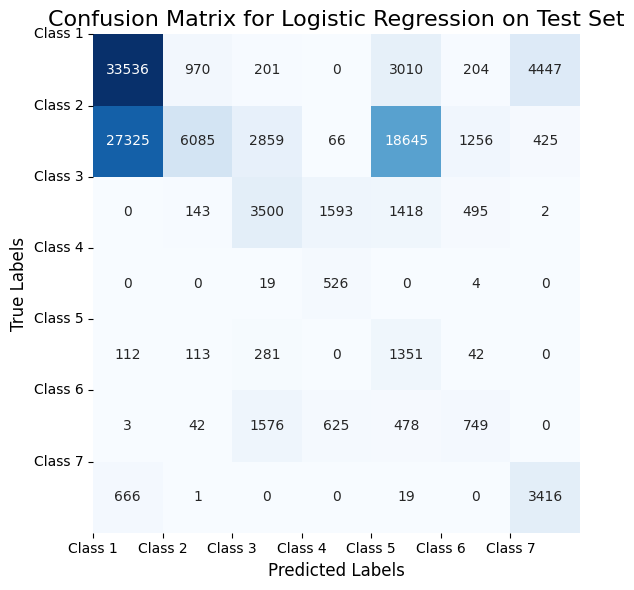

In [ ]:
# Plot the confusion matrix
plt.figure(figsize=(6,6))
sns.heatmap( test_conf_matrix_sgd, annot=True, fmt='g', cmap='Blues', cbar=False)

# Add labels, title, and axes ticks
plt.title('Confusion Matrix for Logistic Regression on Test Set', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3, 4, 5, 6], labels=['Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6', 'Class 7'])
plt.yticks(ticks=[0, 1, 2, 3, 4, 5, 6], labels=['Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6', 'Class 7'], rotation=0)

# Display the confusion matrix
plt.tight_layout()
plt.show()

###KNN df_reversed_Stratified

In [ ]:
#10m Define the parameter grid for KNN
KNN=KNeighborsClassifier()

knn_param_grid = {
    'n_neighbors':  [3, 5, 7, 9, 11, 13, 15, 17, 19] ,
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2] ,
    'metric': ['minkowski', 'euclidean', 'manhattan']

}

random_search_knn = RandomizedSearchCV(
    estimator=KNN,
    param_distributions=knn_param_grid,
    n_iter=250,                # Number of iterations for RandomizedSearchCV
    cv=5,                     # Cross-validation folds
    random_state=42,
    n_jobs=-1,                # Use all available CPU cores for faster computation
    verbose=1,                # Enables progress updates
    error_score=np.nan        # Replace failed fits with np.nan
)

# Fit the RandomizedSearchCV on the scaled undersampled training data
random_search_knn.fit(X_train_undersampled_scaled, y_train_undersampled)

# Get the best parameters found by RandomizedSearchCV for KNN
best_knn_params = random_search_knn.best_params_
print("\nBest Hyperparameters from RandomizedSearchCV for KNN:", best_knn_params)



Fitting 5 folds for each of 250 candidates, totalling 1250 fits

Best Hyperparameters from RandomizedSearchCV for KNN: {'weights': 'distance', 'p': 2, 'n_neighbors': 3, 'metric': 'manhattan', 'algorithm': 'auto'}


In [ ]:
#Train the KNN model using the best parameters on the SMOTE-oversampled and scaled data
best_knn_model = KNeighborsClassifier(**best_knn_params)
best_knn_model.fit(X_train_oversampled_scaled, y_train_oversampled)

KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance')

In [ ]:
# 1m 21s Evaluate the model on the validation set
y_val_pred_knn = best_knn_model.predict(X_val_scaled)
val_accuracy_knn = accuracy_score(y_val_reversed, y_val_pred_knn)
val_conf_matrix_knn = confusion_matrix(y_val_reversed, y_val_pred_knn)
val_class_report_knn = classification_report(y_val_reversed, y_val_pred_knn)

print("\nKNN Validation Set Evaluation on SMOTE-Oversampled Data:")
print("Accuracy:", val_accuracy_knn)
print("Confusion Matrix:\n", val_conf_matrix_knn)
print("Classification Report:\n", val_class_report_knn)

# Evaluate the model on the test set
y_test_pred_knn = best_knn_model.predict(X_test_scaled)
test_accuracy_knn = accuracy_score(y_test_reversed, y_test_pred_knn)
test_conf_matrix_knn = confusion_matrix(y_test_reversed, y_test_pred_knn)
test_class_report_knn = classification_report(y_test_reversed, y_test_pred_knn)

print("\nKNN Test Set Evaluation on SMOTE-Oversampled Data:")
print("Accuracy:", test_accuracy_knn)
print("Confusion Matrix:\n", test_conf_matrix_knn)
print("Classification Report:\n", test_class_report_knn)


KNN Validation Set Evaluation on SMOTE-Oversampled Data:
Accuracy: 0.9360951430243365
Confusion Matrix:
 [[19907  1049     4     0    57     9   158]
 [ 1209 26386   160     1   370   169    35]
 [    0    17  3333    50     9   167     0]
 [    0     0    20   238     0    17     0]
 [    7    35     5     0   898     3     1]
 [    1    10    92    18     5  1611     0]
 [   33     2     0     0     0     0  2016]]
Classification Report:
               precision    recall  f1-score   support

           1       0.94      0.94      0.94     21184
           2       0.96      0.93      0.95     28330
           3       0.92      0.93      0.93      3576
           4       0.78      0.87      0.82       275
           5       0.67      0.95      0.78       949
           6       0.82      0.93      0.87      1737
           7       0.91      0.98      0.95      2051

    accuracy                           0.94     58102
   macro avg       0.86      0.93      0.89     58102
weighted avg

 =>Best Hyperparameters from RandomizedSearchCV for KNN: {'weights': 'distance', 'p': 1, 'n_neighbors': 5, 'metric': 'manhattan', 'algorithm': 'auto'}

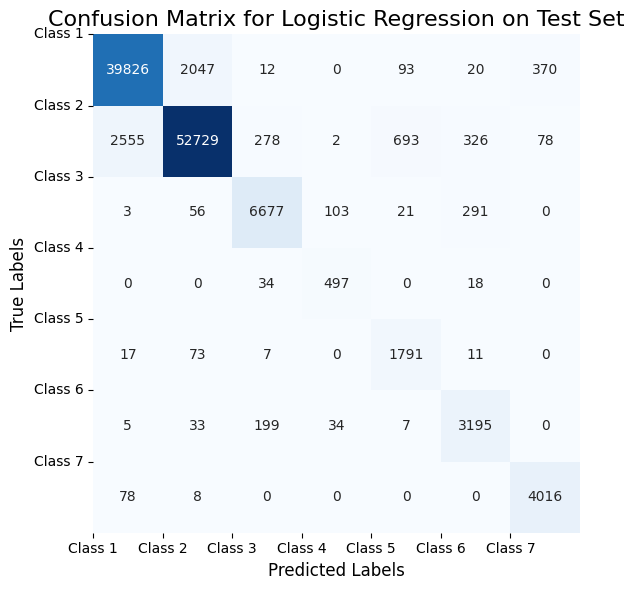

In [ ]:
# Plot the confusion matrix
plt.figure(figsize=(6,6))
sns.heatmap(  test_conf_matrix_knn, annot=True, fmt='g', cmap='Blues', cbar=False)

# Add labels, title, and axes ticks
plt.title('Confusion Matrix for Logistic Regression on Test Set', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3, 4, 5, 6], labels=['Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6', 'Class 7'])
plt.yticks(ticks=[0, 1, 2, 3, 4, 5, 6], labels=['Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6', 'Class 7'], rotation=0)

# Display the confusion matrix
plt.tight_layout()
plt.show()